# Signal Visualization

In [ ]:
%load_ext autoreload
%autoreload 2

import copy
import datetime
import logging
import os
import pickle
import sys
import time
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.optimize as optimize
import torch
import torch.nn as nn
from matplotlib.ticker import StrMethodFormatter
from torch.utils.data import Dataset
from tqdm import tqdm

sys.path.append("..")
from utils import initialize_logging
from models.CNNTransformer import CNNTransformer

# Replace this with your base directory, e.g. "/home/user/projects/dlsa"
BASE_DIR = "/path/to/dlsa"
os.chdir(BASE_DIR)

initialize_logging("SignalVisualization")

# Plot font sizes
SMALL_SIZE = 14
MEDIUM_SIZE = 16
BIGGER_SIZE = 16

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=SMALL_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title

# plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}')) # No decimal places
# plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.2f}')) # 2 decimal places

To produce a figure, first load the residuals, then run the model/data/function definitions for the figure group, and then run the code from the figure section itself.

## Load residuals

The residuals are used throughout this notebook. Always load these first.

In [54]:
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

# Load Fama-French daily data
file_path = os.path.join(BASE_DIR, 'data', 'F-F_Research_Data_5_Factors_2x3_daily.CSV')
FamaFrenchDailyData = pd.read_csv(file_path, index_col=0) / 100
DailyDates = pd.to_datetime(
    FamaFrenchDailyData.index[
        (FamaFrenchDailyData.index > 19980000) & (FamaFrenchDailyData.index < 20170000)
    ],
    format='%Y%m%d'
)

# Residuals configuration
im = 420  # Initial months
w = 20 * 12  # Window size
factor = 5  # Number of factors
capProportion = 0.01  # Capital proportion

# Load residuals
filename = os.path.join(
    BASE_DIR,
    f"residuals-replication/ipca/IPCA_DailyOOSresiduals_{factor}_factors_{im}_initialMonths_{w}_window_{capProportion}_cap.npy"
)
residuals = np.load(filename)
print("Residuals shape:", residuals.shape)

Residuals shape: (4781, 9483)


## Figure group: 14, 15, 16, 19

### Data/model loading

In [47]:
normalizationConv = True
filter_numbers = [1,8]
dropout = 0.25
attention_heads = 4
num_heads = attention_heads
hidden_units = 16
filter_size = 2
useTransformer = True
device = 'cpu'
lookback = 30

model = CNNTransformer(
    random_seed=0,
    lookback=30,
    device="cpu",
    normalization_conv=normalizationConv,
    filter_numbers=filter_numbers,
    attention_heads=attention_heads,
    use_convolution=True,
    hidden_units=hidden_units,
    dropout=dropout,
    filter_size=filter_size,
    use_transformer=useTransformer
)
# model = nn.DataParallel(model, device_ids=device_ids).to(device)

In [53]:
# load model
def load_model(path):
    # format of saved .tar file is a dictionary with:
    # checkpoint = {
    #     'epoch': epoch,
    #     'model_state_dict': model.state_dict(),
    #     'optimizer_state_dict': optimizer.state_dict(),
    #     'loss': loss}
    checkpoint = torch.load(path)
    from collections import OrderedDict
    state_dict = checkpoint['model_state_dict']
    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        print(f'loading {k}')  # , norm: {np.linalg.norm(v.cpu().numpy())}')
        name = k[7:] # remove `module.`
        new_state_dict[name] = v
    model.load_state_dict(new_state_dict)
    model.eval()
    return model

model_path = 'saved-results/cnn_transformer/Checkpoint-0_seed_IPCA5_0transCost_0holdCost_residualWeights_SharpeNoRetrain_normalized_CNNTransformer_30lookback_2012lengthTraining_[1, 8]filters_4attention_0.25dropout_16hiddenunits_recalibration0.tar'
model = load_model(model_path)

# set hooks which capture intermediate outputs
activations = {}
inputs = {}
def get_activation(name):
    def hook(model, input, output):
        if name == 'convout':
            # print(output)
            # print(output.shape)
            # activations[name] = output[1].detach()
            activations[name] = output.detach()
        elif type(output) is tuple:
            # print(len(output))
            # print(output[0].shape)
            # print(output[1].shape)
            activations[name] = output[0].detach()
        else:
            activations[name] = output.detach()
    return hook
def get_input(name):
    def hook(model, input, output):
        inputs[name] = input.detach()
    return hook

handle_out1 = model.encoder.dropout2.register_forward_hook(get_activation('transformerout'))
handle_out2 = model.convBlocks[0].register_forward_hook(get_activation('convout'))
handle_out3 = model.encoder.self_attn.register_forward_hook(get_activation('signals'))

/tmp/ipykernel_186290/972214455.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path)


loading module.convBlocks.0.conv1.weight
loading module.convBlocks.0.conv1.bias
loading module.convBlocks.0.conv2.weight
loading module.convBlocks.0.conv2.bias
loading module.encoder.self_attn.in_proj_weight
loading module.encoder.self_attn.in_proj_bias
loading module.encoder.self_attn.out_proj.weight
loading module.encoder.self_attn.out_proj.bias
loading module.encoder.linear1.weight
loading module.encoder.linear1.bias
loading module.encoder.linear2.weight
loading module.encoder.linear2.bias
loading module.encoder.norm1.weight
loading module.encoder.norm1.bias
loading module.encoder.norm2.weight
loading module.encoder.norm2.bias
loading module.linear.weight
loading module.linear.bias


In [49]:
# check dimensionality
assert(model(torch.ones(3,30)).shape == torch.Size([3]))
assert(activations['signals'].shape == torch.Size([30,3,8]))

### Signal and allocation weights for residuals (Figure 14)

In [50]:
# Font size in plots
SMALL_SIZE = 11
MEDIUM_SIZE = 11
BIGGER_SIZE = 11

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=SMALL_SIZE)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

SIM_PLOT_DIR = "plots/visualizations"
if not os.path.isdir(SIM_PLOT_DIR):
    os.mkdir(SIM_PLOT_DIR)

In [51]:
def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

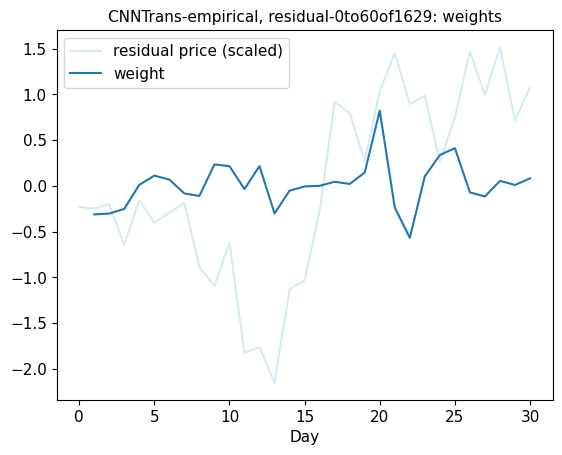

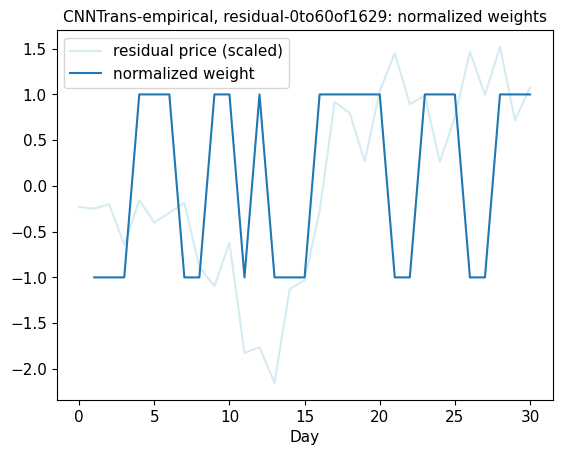

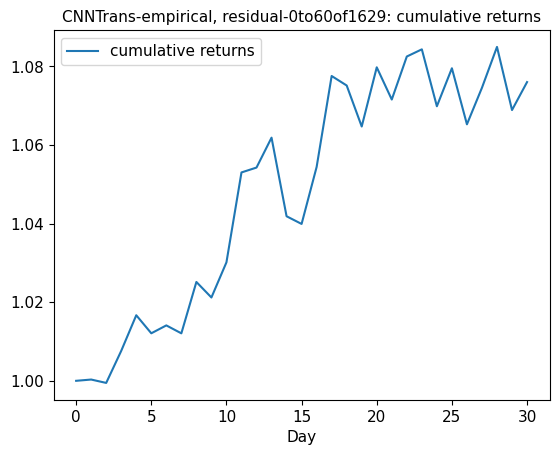

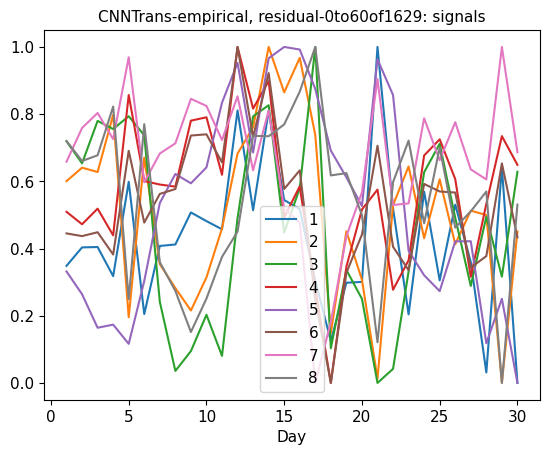

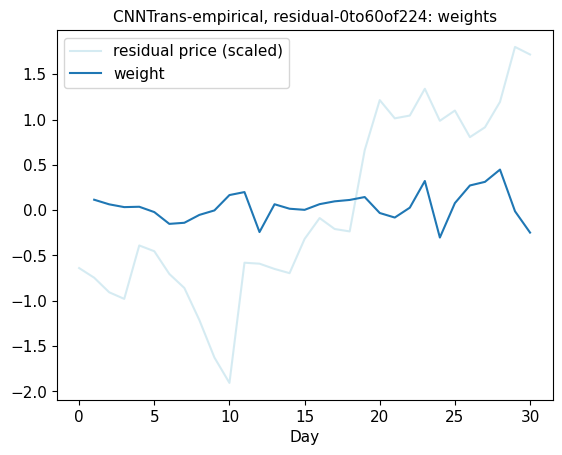

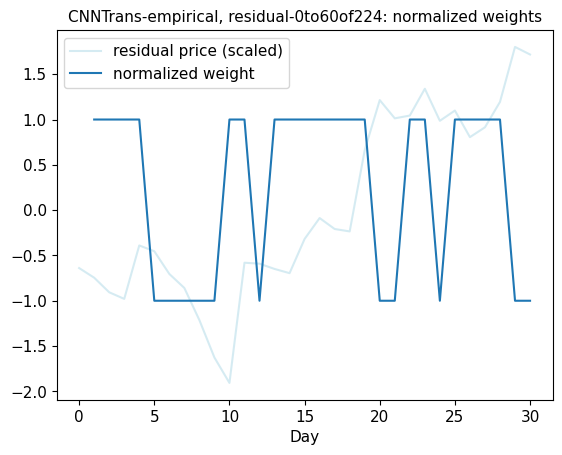

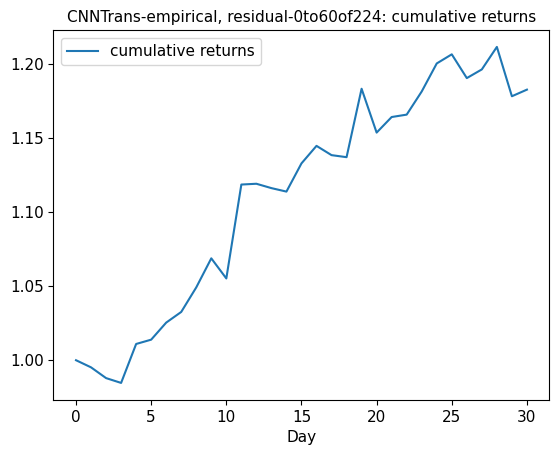

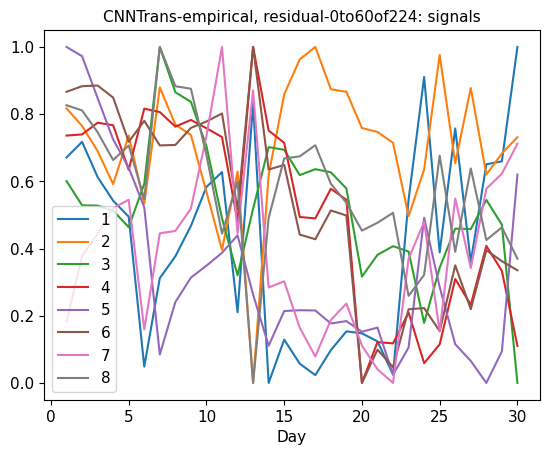

<Figure size 640x480 with 0 Axes>

In [52]:
def msn(x):
    return (x - np.mean(x))/np.std(x)

def mn(x):
    return x - np.mean(x)

def mmn(x):
    m1 = np.min(x)
    m2 = np.max(x)
    return (x-m1)/(m2-m1)

# model.cuda()

model_name = "CNNTrans-empirical"
param_labels = ["1","2","3","4",'5','6','7','8']

lookback = 30
residual_examples = [
    # (30,90,394),
    # (0,60,2894),
    # (0,60,1709),
    # (0,60, 955),
    # (0,60,1734),
    # (0,60, 215),
    # (0,60,3126),
    # (0,60,1578),
    (0,60,1629),
    (0,60, 224),
]
residual_data = {
    f'{t1}to{t2}of{i}': np.cumsum(residuals[t1:t2,i])
    for (t1,t2,i) in residual_examples
}

cumrets = np.zeros((len(residual_data), 30))
for (data_name,d) in residual_data.items():
    outs = np.zeros(30)
    params = np.zeros((30,len(param_labels)))
    for t in range(30,60):
        inputs = d[(t-lookback):t,np.newaxis].T #(N,T)
        inputs = torch.tensor(inputs, dtype=torch.float, device=device)
        output = model(inputs)
        #try:
        outs[t-lookback] = output
        #except:
        #    outs[t-lookback] = 0
        signals = activations['signals'][-1,:,:].cpu().numpy().ravel()
        params[t-lookback,:] = signals
    # print(outs)
    srp = msn(d[29:])  # 29 to 60 to have 31 days plotted, where index 0 has no trading
    plt.plot(srp, color='lightblue', label='residual price (scaled)', alpha=0.5)
    plt.plot(np.concatenate([np.ones(1)*np.nan,outs]),label='weight')
    plt.legend()
    plt.xlabel("Day")
    plt.title(f"{model_name}, residual-{data_name}: weights")
    plt.savefig(f"{SIM_PLOT_DIR}/residual-{model_name}-{data_name}-weights.png")
    plt.figure()
    plt.plot(srp, color='lightblue', label='residual price (scaled)', alpha=0.5)
    # weight on day 0 is zero, as no trading occurs on that day
    plt.plot(np.concatenate([np.ones(1)*np.nan,np.sign(outs)]), label='normalized weight')
    plt.legend()
    plt.xlabel("Day")
    plt.title(f"{model_name}, residual-{data_name}: normalized weights")
    plt.savefig(f"{SIM_PLOT_DIR}/residual-{model_name}-{data_name}-normalized_weights.png")
    plt.figure()
    
    rets = np.zeros(30)
    for i in range(30,60):
        rets[i-30] = d[i] - d[i-1]
    # print(data_name, rets.min(), rets.max())
    strat_rets = np.sign(outs) * rets
    cumrets = np.cumprod(1+strat_rets)
    # print(len(cumrets))
    # day 0 has active trading (and thus no weight; see above) and thus cumulative return on day zero is 1
    plt.plot(np.concatenate([np.ones(1),cumrets]), label='cumulative returns')
    plt.legend()
    plt.xlabel("Day")
    plt.title(f"{model_name}, residual-{data_name}: cumulative returns")
    plt.savefig(f"{SIM_PLOT_DIR}/residual-{model_name}-{data_name}-cumulative_returns.png")
    plt.figure()
    
    for pidx in range(params.shape[1]):
        pr = params[:,pidx]
        plt.plot(np.concatenate([np.ones(1)*np.nan,mmn(pr)]), label=param_labels[pidx])
    plt.legend()
    plt.xlabel("Day")
    plt.title(f"{model_name}, residual-{data_name}: signals")
    plt.savefig(f"{SIM_PLOT_DIR}/residual-{model_name}-{data_name}-signals.png")
    plt.figure()

### Normalized average absolute gradient plots (Figure 19)

First, definitions of the functions that we need to compute gradients for. The model itself (for gradient of output wrt input residual) doesn't need one of these, as we just use the `model` function itself for this.

In [15]:
def linear(Input, weight, bias=None):
    """
    Applies a linear transformation to the Input tensor
    """
    if Input.dim() == 2 and bias is not None:
        # fused op is marginally faster
        ret = torch.addmm(bias, Input, weight.t())
    else:
        output = Input.matmul(weight.t())
        if bias is not None:
            output += bias
        ret = output
    return ret

def softmax(Input, dim=None, dtype=None):
    """
    Computes softmax in a numerically stable way for the given input tensor.
    """
    if dtype is None:
        ret = Input.softmax(dim)
    else:
        ret = Input.softmax(dim, dtype=dtype)
    return ret

def moving_average(a, n=30, axis=1):
    """
    Creates a simple moving average for the matrix a, with a window size of n, along the given axis
    """
    ret = np.cumsum(a,axis)
    N = a.shape[axis]
    if axis == 0:
        ret[n:] = ret[n:] - ret[:-n] # np.take(ret, range(n,N), axis=axis) - np.take(ret, range(0,N-n), axis=axis, out = )
        try:
            ret[:n - 1] = ret[:n-1] / np.linspace(1,min(n-1,N),min(n-1, N))
        except:
            ret[:n - 1] = ret[:n-1] / np.linspace(1,min(n-1,N),min(n-1, N)).reshape((min(n-1,N),1))
        ret[n - 1:] = ret[n - 1:] / n
    elif axis == 1:
        ret[:,n:] = ret[:,n:] - ret[:,:-n] # np.take(ret, range(n,N), axis=axis) - np.take(ret, range(0,N-n), axis=axis, out = )
        ret[:,:n - 1] = ret[:,:n-1] / np.linspace(1,min(n-1,N),min(n-1, N)).reshape((min(n-1,N),1))
        ret[:,n - 1:] = ret[:,n - 1:] / n
    else:
        raise Exception(f"Invalid axis for moving average '{axis}'")
    return ret

def model_cnn_output_in(x):
    """
    Computes the output of the CNN part of the model, given a Nx8x30 input tensor
    """
    # takes in a Nx8x30 convolutional input
    x = x.permute(2,0,1)
    x = model.encoder(x)  # the input of the transformer is (T,N,C)
    return model.linear(x[-1,:,:]).squeeze()  # this outputs the weights #self.softmax(x[-1,:,:]) #(N,num_classes)

def model_transformer_output_in(x):
    """
    Computes the output of the transformer part of the model, given a 1xNx8 input tensor
    """
    # this takes in a 1xNx8 tensor, the last element of the 30xNx8 transformer output
    return model.linear(x).squeeze()

def model_attn_output_in(x):
    """
    Computes the output of just the attention part of the model, given a 30xNx8 input tensor of convolutional output
    """
    # takes in 30x8xN vector of self-attn output
    # Implementation of Feedforward model in TransformerEncoder layer
    x = model.encoder.norm1(x)
    x = model.encoder.linear2(model.encoder.activation(model.encoder.linear1(x)))
    x = model.encoder.norm2(x)
    # Return linear layer output
    return model.linear(x[-1,:,:]).squeeze()

def model_h_l_in(indata):
    """
    Computes the output of the model, given a 30xNx8 input tensor (the convolutional output)
    """
    # un-concatenate the input data
    cnn_out = indata[:,:,:8]
    attn_output = indata[:,:,8:]
    # get projection weights and biases
    out_proj_weight = model.encoder.self_attn.out_proj.weight
    out_proj_bias = model.encoder.self_attn.out_proj.bias
    # takes in 30xNx8 vector of h_l output
    attn_output2 = linear(attn_output, out_proj_weight, out_proj_bias)
    activations['attnout_piecemeal'] = attn_output2.detach().cpu().numpy()
    # Feedforward model in Transformer encoder layer
    # src = src + self.dropout1(src2)
    # src = self.norm1(src)
    # src2 = self.linear2(self.dropout(self.activation(self.linear1(src))))
    # src = src + self.dropout2(src2)
    # src = self.norm2(src)
    src = cnn_out
    src2 = attn_output2
    # print(f"src.shape {src.shape} src2.shape {src2.shape}")
    src = src + src2
    src = model.encoder.norm1(src)
    src2 = model.encoder.linear2(model.encoder.activation(model.encoder.linear1(src)))
    src = src + src2
    src = model.encoder.norm2(src)
    # Return linear layer output
    return model.linear(src[-1,:,:]).squeeze()

def h_l(indata):
    """
    Computes h_l (the 8x30 matrix), last element of which is h_L
    Also saves attention weights and other things in `activations` dict, which must be present in global state of program
    """
    N,T = indata.shape
    x = indata.reshape((N,1,T))  #(N,1,T)
    # x = model.convBlocks[0](x)[0]
    x = model.convBlocks[0](x)
    activations['convout_piecemeal'] = x.detach().cpu().numpy()
    x = x.permute(2,0,1)
    in_proj_weight = model.encoder.self_attn.in_proj_weight
    in_proj_bias = model.encoder.self_attn.in_proj_bias
    query = x
    src_len = lookback
    tgt_len, bsz, embed_dim = query.shape #(lookback, N,filters)
    print(tgt_len, bsz, embed_dim)
    head_dim = embed_dim // num_heads
    scaling = float(head_dim) ** -0.5
    q, k, v = linear(query, in_proj_weight, in_proj_bias).chunk(3, dim=-1)
    q = q.contiguous().view(tgt_len, bsz * num_heads, head_dim).transpose(0, 1)
    k = k.contiguous().view(-1, bsz * num_heads, head_dim).transpose(0, 1)
    v = v.contiguous().view(-1, bsz * num_heads, head_dim).transpose(0, 1)
    q = q * scaling
    attn_output_weights = torch.bmm(q, k.transpose(1, 2))
    attn_output_weights = softmax(attn_output_weights, dim=-1)
    attn_output = torch.bmm(attn_output_weights, v)
    attn_output = attn_output.transpose(0, 1).contiguous().view(tgt_len, bsz, embed_dim)
    activations['attn_v'] = v.view(bsz, num_heads, tgt_len, head_dim).detach()
    activations['attn_weights'] = attn_output_weights.view(bsz, num_heads, tgt_len, src_len).detach()
    activations['attn_h_l'] = attn_output.detach()
    return attn_output.detach(), x.detach()  # h_L is attn_output[-1,:,:]
    
def compute_self_attn_things(indata):
    """
    Given input residual time series tensor x (a cumulative residual torch tensor):
    - saves attention weights and h_l to activations
    - computes gradient of output wrt h_l
    """
    h_l_out, cnn_out = h_l(indata)
    print(f"h_l_out.shape {h_l_out.shape}")
    # concatenate them for model_h_l_in
    input_concat = torch.cat([cnn_out, h_l_out], axis=2)  # 30xNx16
    piecemeal_output = model_h_l_in(input_concat)
    # check to make sure output is equal
    model_output = model(indata)
    print(f"h_l output vs model output: {np.linalg.norm(model_output.detach().cpu().numpy() - piecemeal_output.detach().cpu().numpy())}")
    # print(f"model_out.shape vs h_l_out.shape {model_output.shape} {piecemeal_output.shape}")
    # copy activations to fixed_activations dict
    fixed_activations['attn_v'] = copy.deepcopy(activations['attn_v'])
    fixed_activations['attn_weights'] = copy.deepcopy(activations['attn_weights'])
    fixed_activations['attn_h_l'] = copy.deepcopy(activations['attn_h_l'])
    # now compute gradients (which will change `activations` dict)
    grad_output_wrt_h_l = calculate_avg_absolute_jacobian(model_h_l_in, input_concat, batch_axis=1)
    # return things
    return grad_output_wrt_h_l #, attn_weights, attn_h_l, attn_v

In [16]:
def calculate_avg_absolute_jacobian(func, indata, batch_axis, numpy_out=True):
    """
    Calculate the average of the absolute Jacobian of the function `func` wrt the input data observations `indata`.
    `indata` should have one observation of input data per element of the index `batch_axis`;
    e.g. so if batch_axis=1, then indata[0,:,:] is the first observation, indata[1,:,:] the second observation, etc.
    e.g. so if batch_axis=2, then indata[:,0,:] is the first observation, indata[:,1,:] the second observation, etc.
    e.g. so if batch_axis=3, then indata[:,:,0] is the first observation, indata[:,:,1] the second observation, etc.
    To get out a Numpy array, let numpy_out=True (otherwise it's torch)
    
    NOTE: make sure any input is NOT the result of a hook! Examples include output of intermediate layers. Calling
    torch,autograd.functional.jacobian on the model which produced an intermediate output WILL affect the activations
    dictionary. Make sure to deepcopy any indata before giving it to this function, if necessary.
    """
    batch = 5
    num_observations = indata.shape[batch_axis]
    avg_jacobian = None
    if len(indata.shape) == 2:
        if   batch_axis == 0:
            avg_jacobian = torch.zeros_like(torch.autograd.functional.jacobian(func, indata[0:1,:])).squeeze()
        else:
            raise Exception(f"Invalid batch_axis '{batch_axis}'; batch axis must be 0 (transpose input if this is not the case)")
    elif len(indata.shape) == 3:
        if   batch_axis == 0:
            avg_jacobian = torch.zeros_like(torch.autograd.functional.jacobian(func, indata[0:1,:,:])).squeeze()
        elif batch_axis == 1:
            avg_jacobian = torch.zeros_like(torch.autograd.functional.jacobian(func, indata[:,0:1,:])).squeeze()
        elif batch_axis == 2:
            avg_jacobian = torch.zeros_like(torch.autograd.functional.jacobian(func, indata[:,:,0:1])).squeeze()
        else:
            raise Exception(f"Invalid batch_axis '{batch_axis}'; batch axis must be less than 3")
    else:
        raise Exception(f"Invalid input data dimensions '{indata.shape}'; 4+-dimensional input are not yet implemented in this function")
    print(f"Average jacobian shape: {avg_jacobian.shape}")
    
    for i in range(0, num_observations, batch):
        if len(indata.shape) == 2:
            if batch_axis == 0:
                G = torch.abs(torch.autograd.functional.jacobian(func, indata[i:i+batch,:]))
                G = G.diagonal().t().sum(axis=batch_axis)
            else:
                raise Exception(f"Invalid batch_axis '{batch_axis}'; batch axis must be 0 (transpose input if this is not the case)")
        elif len(indata.shape) == 3:
            if batch_axis == 0:
                G = torch.abs(torch.autograd.functional.jacobian(func, indata[i:i+batch,:,:]))  # batch x batch x F x L e.g. 5x5x8x30
                G = G.diagonal().transpose(0,2).sum(axis=batch_axis).t()  # F x L e.g. 8x30
            elif batch_axis == 1:
                G = torch.abs(torch.autograd.functional.jacobian(func, indata[:,i:i+batch,:]))
                G = G.diagonal(dim1=0,dim2=2).transpose(1,2).sum(axis=batch_axis)  # L x F e.g. 30x8
            else:
                raise Exception(f"Invalid batch_axis '{batch_axis}'; batch axis must be 0 (for CNN output) or 1 (for attention output)")
        else:
            raise Exception(f"Invalid input data dimensions '{indata.shape}'; 4+-dimensional input are not yet implemented in this function")
        if i % 200 == 0 or abs(i - num_observations) <= batch:
            print(f"At {i} of {num_observations}")
            print(f"G.shape {G.shape}")
        avg_jacobian += G
    avg_jacobian /= num_observations
    if numpy_out:
        return avg_jacobian.detach().cpu().numpy()
    else:
        return avg_jacobian.detach().cpu()

In [17]:
num_heads = 4
model.cpu()

CNNTransformer(
  (convBlocks): ModuleList(
    (0): CNN_Block(
      (conv1): Conv1d(1, 8, kernel_size=(2,), stride=(1,))
      (conv2): Conv1d(8, 8, kernel_size=(2,), stride=(1,))
      (relu): ReLU(inplace=True)
      (left_zero_padding): ConstantPad1d(padding=(1, 0), value=0)
      (normalization1): InstanceNorm1d(1, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
      (normalization2): InstanceNorm1d(8, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    )
  )
  (encoder): TransformerEncoderLayer(
    (self_attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=8, out_features=8, bias=True)
    )
    (linear1): Linear(in_features=8, out_features=16, bias=True)
    (dropout): Dropout(p=0.25, inplace=False)
    (linear2): Linear(in_features=16, out_features=8, bias=True)
    (norm1): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
    (norm2): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
    (dropout1)

In [18]:
signal_values = np.zeros((residuals.shape[0]//30, residuals.shape[1], 8))
signal_examples = []
# avg_g_input = np.zeros(30)
# avg_g_conv = np.zeros((8,30))
# avg_g_signal = np.zeros(8)
# avg_g_attn_output = np.zeros((30,8))
# avg_g_h_l = np.zeros((30,8))

for t in range(lookback, residuals.shape[0], lookback):
    if t > lookback:
        break        
    valid_mask = np.where(~np.any(residuals[0:30,:] == 0, axis = 0).ravel())[0]
    inputs_tensor = torch.tensor(np.cumsum(residuals[t-lookback:t,valid_mask], axis=0).T, dtype=torch.float)
    output = model(inputs_tensor).detach().cpu().numpy().ravel()
    fixed_activations = copy.deepcopy(activations)
    avg_g_input = calculate_avg_absolute_jacobian(model, inputs_tensor, batch_axis=0)
    avg_g_conv = calculate_avg_absolute_jacobian(model_cnn_output_in, fixed_activations['convout'], batch_axis=0)
    avg_g_signal = calculate_avg_absolute_jacobian(model_transformer_output_in, fixed_activations['signals'][-1,:,:], batch_axis=0)
    avg_g_h_l = compute_self_attn_things(inputs_tensor)[:,8:]  # gradient is a concatenated in last axis: (conv gradient 0:8, h_l gradient 8:16)
    signal_values[t-lookback,valid_mask,:] = fixed_activations['signals'][-1,:,:].detach().cpu().numpy()

Average jacobian shape: torch.Size([30])
At 0 of 813
G.shape torch.Size([30])
At 200 of 813
G.shape torch.Size([30])
At 400 of 813
G.shape torch.Size([30])
At 600 of 813
G.shape torch.Size([30])
At 800 of 813
G.shape torch.Size([30])
At 810 of 813
G.shape torch.Size([30])
Average jacobian shape: torch.Size([8, 30])
At 0 of 813
G.shape torch.Size([8, 30])
At 200 of 813
G.shape torch.Size([8, 30])
At 400 of 813
G.shape torch.Size([8, 30])
At 600 of 813
G.shape torch.Size([8, 30])
At 800 of 813
G.shape torch.Size([8, 30])
At 810 of 813
G.shape torch.Size([8, 30])
Average jacobian shape: torch.Size([8])
At 0 of 813
G.shape torch.Size([8])
At 200 of 813
G.shape torch.Size([8])
At 400 of 813
G.shape torch.Size([8])
At 600 of 813
G.shape torch.Size([8])
At 800 of 813
G.shape torch.Size([8])
At 810 of 813
G.shape torch.Size([8])
30 813 8
h_l_out.shape torch.Size([30, 813, 8])
h_l output vs model output: 1.905018848447071e-06
Average jacobian shape: torch.Size([30, 16])
At 0 of 813
G.shape torc

In [ ]:
np.save('avg_g_input.npy', avg_g_input)
np.save('avg_g_conv.npy', avg_g_conv)
np.save('avg_g_signal.npy', avg_g_signal)
np.save('avg_g_h_l.npy', avg_g_h_l)

Text(0, 0.5, 'Normalized average absolute gradient')

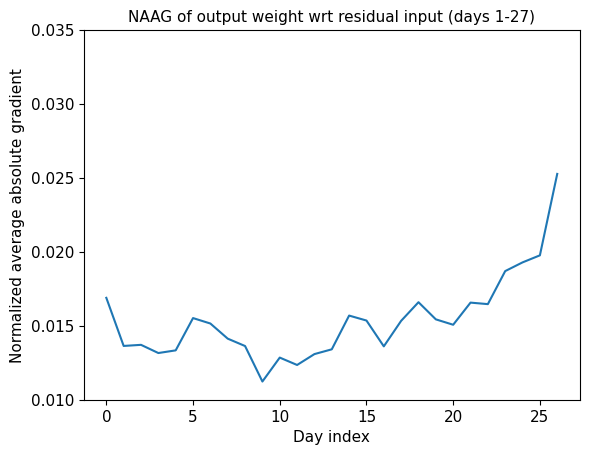

In [ ]:
#plt.figure(figsize=(12,8))
plt.plot((avg_g_input/avg_g_input.sum())[:27])
plt.title("NAAG of output weight wrt residual input (days 1-27)")
plt.xlabel("Day index")
plt.ylim(0.01,0.035)
plt.ylabel("Normalized average absolute gradient")
# plt.savefig(f"{SIM_PLOT_DIR}/interpretation/naag-input-days-1-27.png")

Text(0, 0.5, 'Normalized average absolute gradient')

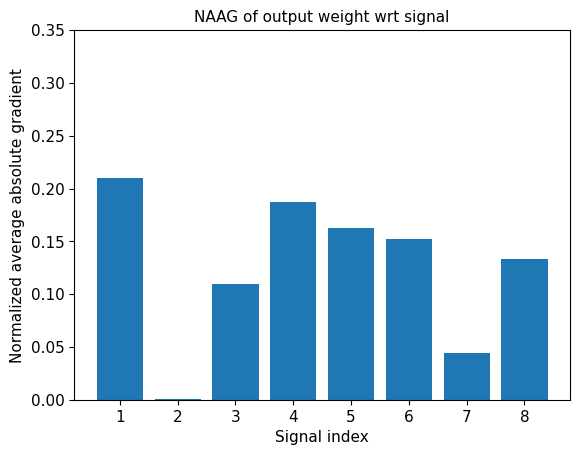

In [ ]:
#plt.figure(figsize=(12,8))
plt.bar(range(1,9), avg_g_signal/avg_g_signal.sum())
plt.title("NAAG of output weight wrt signal")
plt.xlabel("Signal index")
plt.ylim(0,0.35)
plt.ylabel("Normalized average absolute gradient")
# plt.savefig(f"{SIM_PLOT_DIR}/interpretation/naag-signal.png")

### Attention weight visualization for sine-like functions (Figure 16)

Here we simulate various sine-like functions and look at the generated attention weights to see if they look sinusoidal.

First we do this manually in NumPy to gain some intuition, on a basic sum of sines.

In [22]:
K = model.encoder.self_attn.in_proj_weight[:8,:].detach().numpy() @ model.encoder.self_attn.in_proj_weight[8:16,:].detach().numpy().T

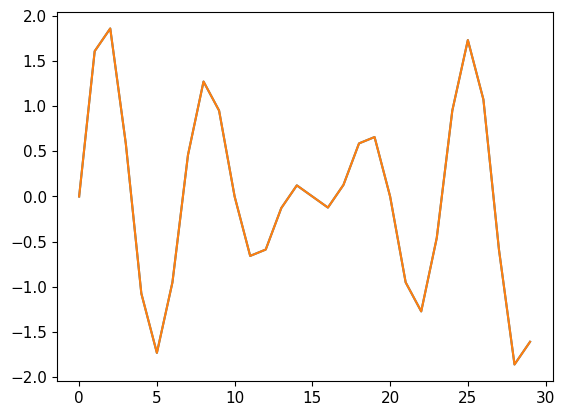

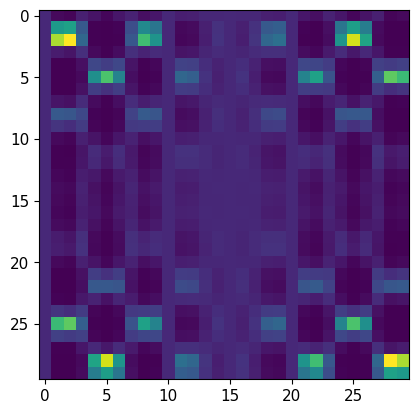

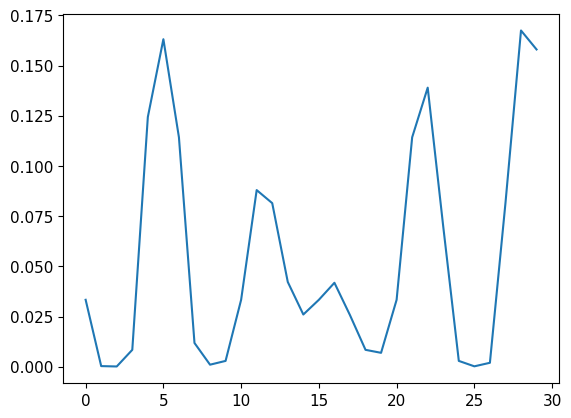

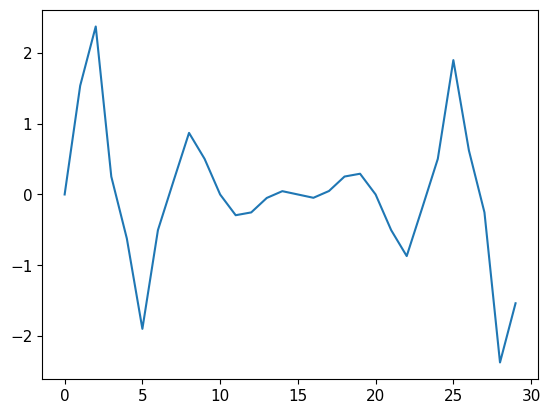

In [23]:
x = np.sin(np.arange(30)*2*np.pi*4/30) + np.sin(np.arange(30)*2*np.pi*5/30)
plt.plot(x)
x = x[np.newaxis,:].T
plt.plot(x)
c = 1.2

W = np.exp(c * x @ x.T)
W /= np.sum(W, axis=0)
plt.figure()
plt.imshow(W)
plt.figure()
plt.plot(W[29,:])
plt.figure()
plt.plot(W@x)

def a_L(y):
    x[-1,:] = y
    W = np.exp(c * x @ x.T)
    W /= np.sum(W, axis=0)

Now, we carry out this process for a full set of sinusoidal inputs, using the network weights.

In [24]:
sin_in = np.zeros((30,30))
for i in range(30):
    sin_in[i,:] = np.sin(np.arange(30)*2*np.pi*i/30)

sin2_in = np.zeros((900,30))
for i in range(30):
    for j in range(30):
        sin2_in[j+i*j,:] = np.sin(np.arange(30)*2*np.pi*i/30) + np.sin(np.arange(30)*2*np.pi*j/30)

sin_in = torch.tensor(sin_in, dtype=torch.float)
sin2_in = torch.tensor(sin2_in, dtype=torch.float)
sin_output = model(sin_in)
sin2_output = model(sin2_in)
sin_h_l = h_l(sin_in)
sin_attn_weights = copy.deepcopy(activations['attn_weights'])
print(sin_attn_weights.shape)
sin2_h_l = h_l(sin2_in)
sin2_attn_weights = copy.deepcopy(activations['attn_weights'])
print(sin2_attn_weights.shape)

30 30 8
torch.Size([30, 4, 30, 30])
30 900 8
torch.Size([900, 4, 30, 30])


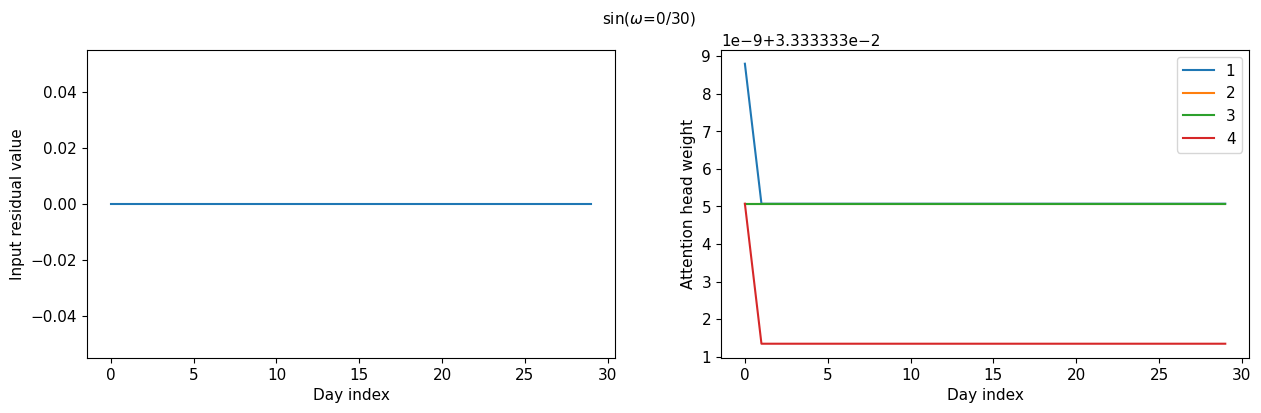

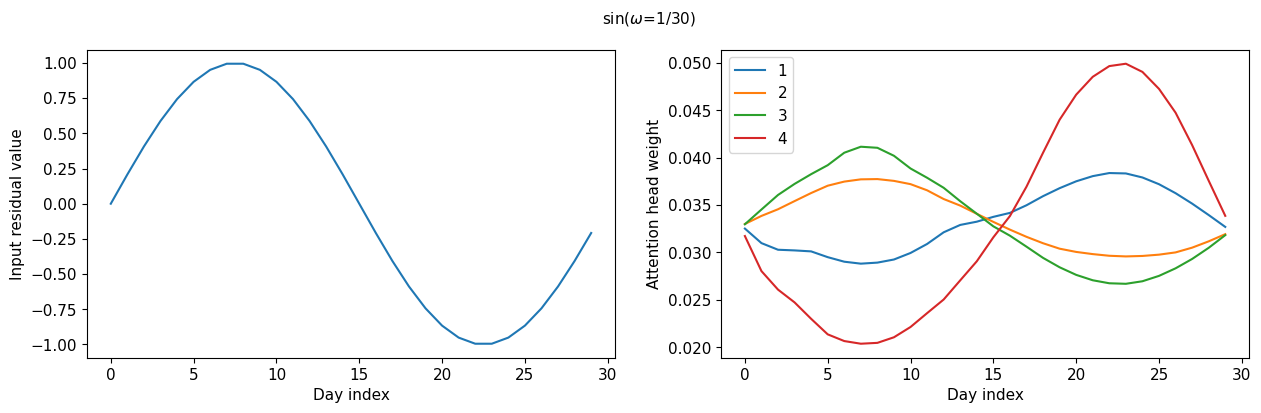

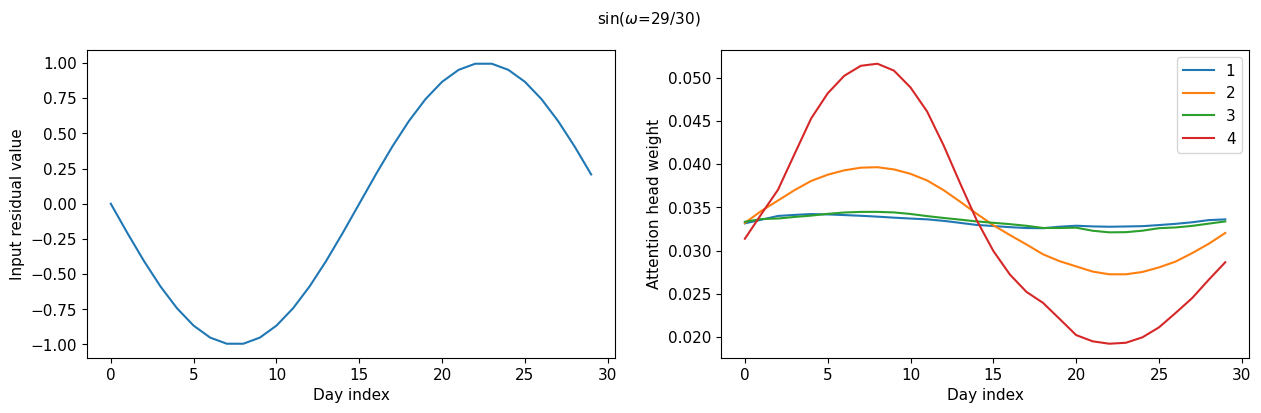

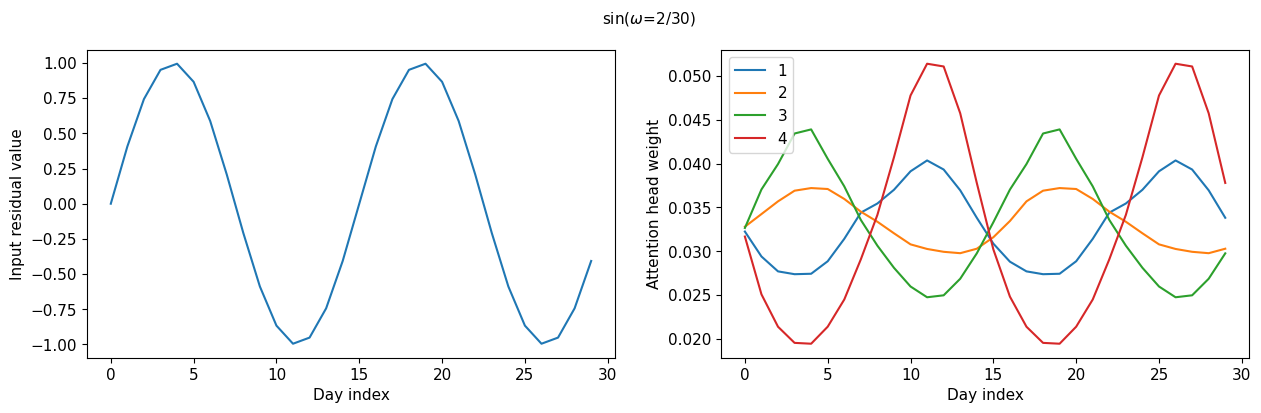

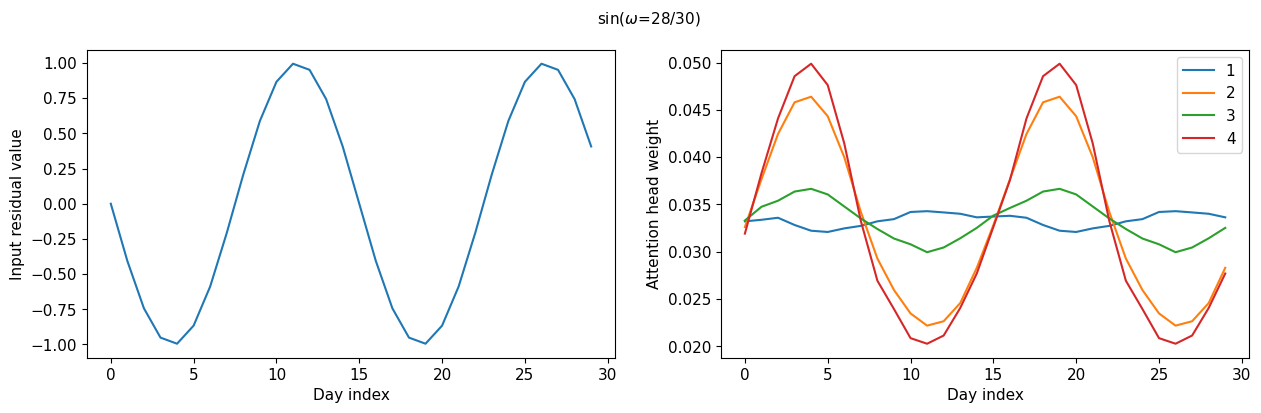

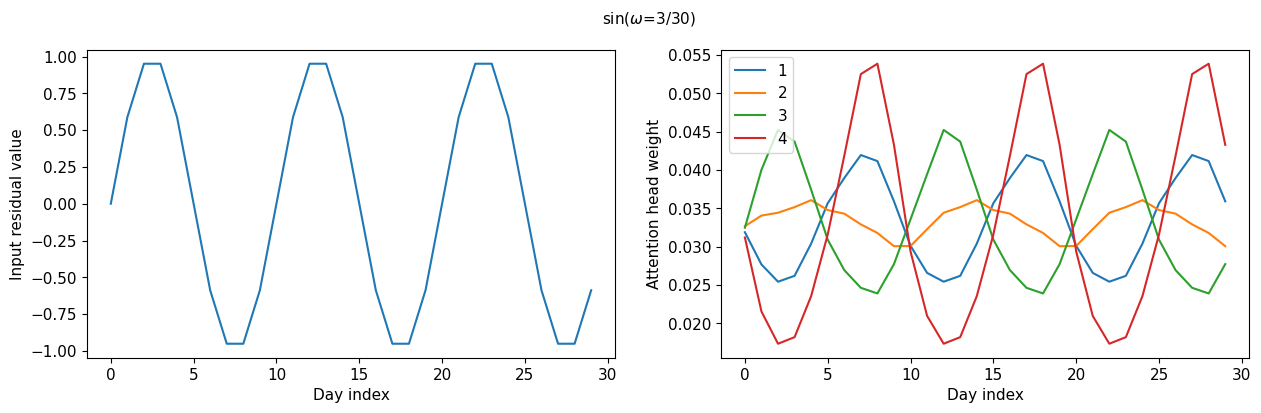

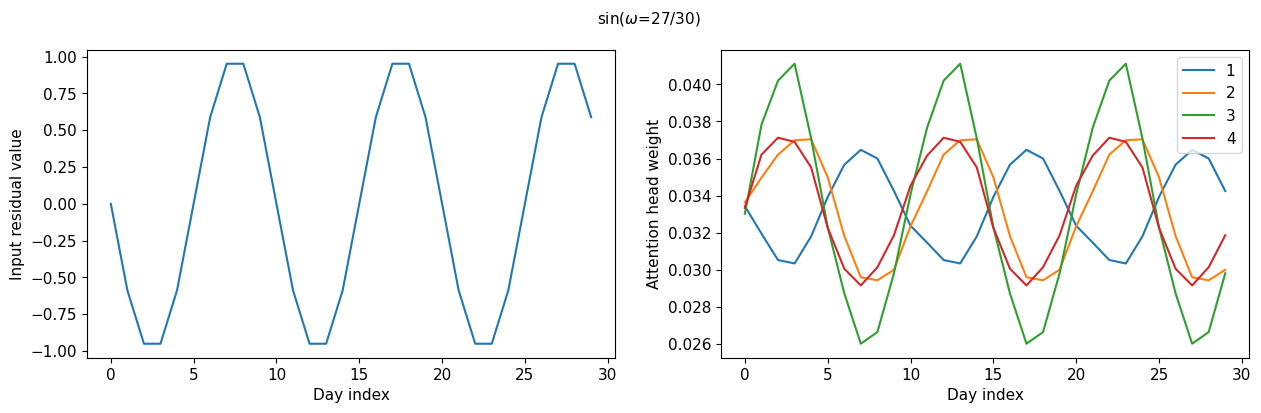

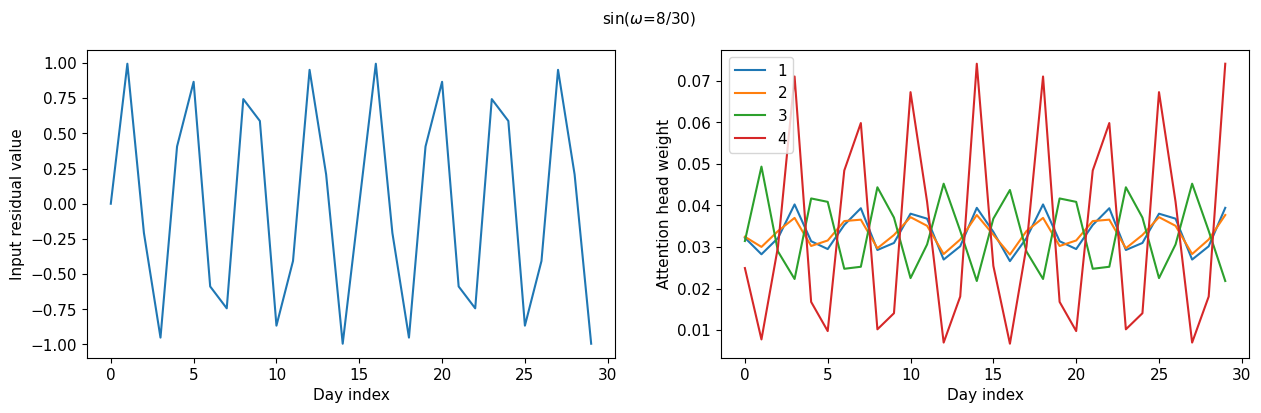

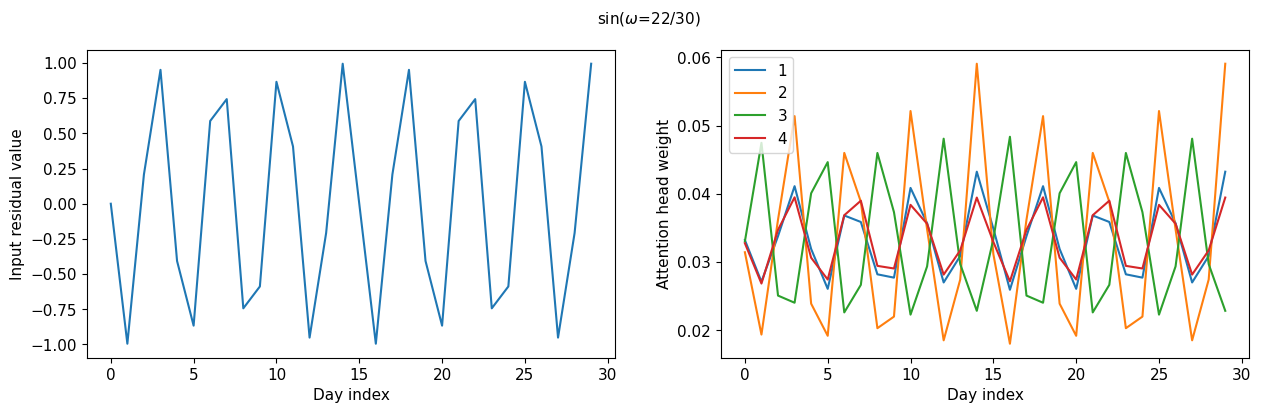

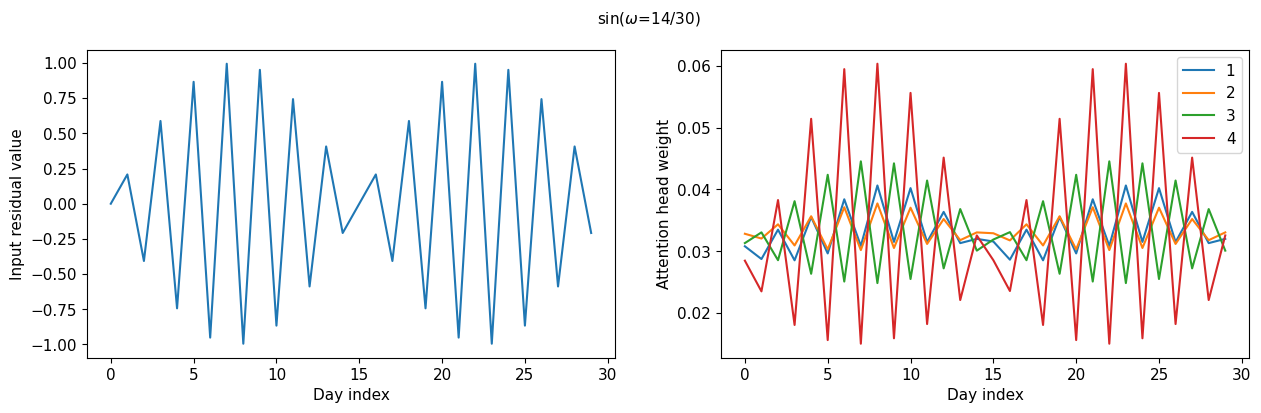

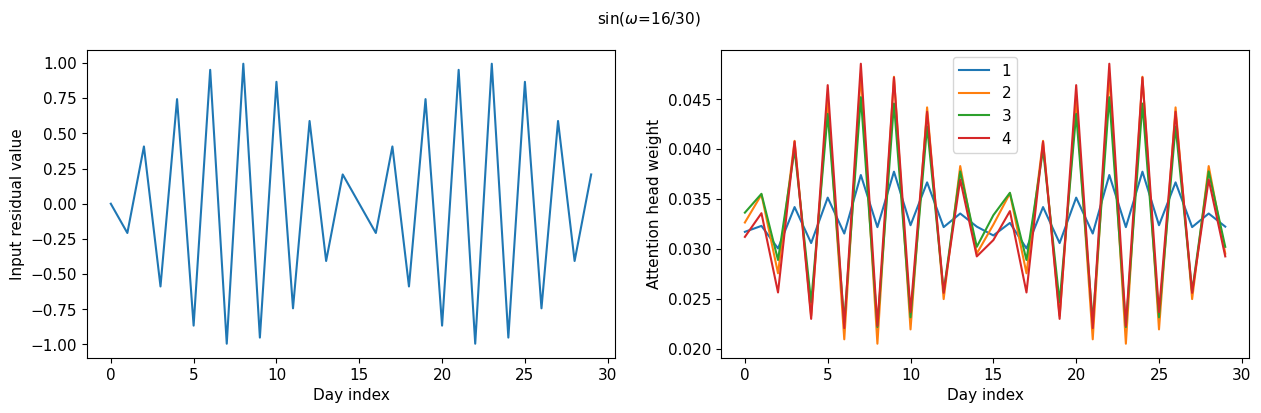

In [ ]:
for i in [0, 1,29, 2,28, 3,27, 8,22, 14,16]:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,4))
    ax1.plot(sin_in[i,:])
    w_L = sin_attn_weights[i,:,-1,:]
    for h in range(4):
        ax2.plot(w_L[h,:], label=str(h+1))
    ax2.legend()
    ax1.set_xlabel("Day index")
    ax2.set_xlabel("Day index")
    ax1.set_ylabel("Input residual value")
    ax2.set_ylabel("Attention head weight")
    fig.suptitle(f"sin($\omega$={i}/30)")
    # plt.savefig(f"{SIM_PLOT_DIR}/interpretation/example-attention-weights-{i}_30.png")

### Model attention/convolution factors interpretation (Figure 15)

In [26]:
import torch
import torch.nn as nn
from torch import tensor
from torch.utils.data import Dataset

# Hyperparameters
num_epochs = 24 
learning_rate = 0.001
optimizer = 'Adam'
input_dim = 60
filter_size = 2
filter_numbers = [1,8]
num_conv_blocks = len(filter_numbers)-1
dropout = 1-0.75
attention_heads = 4
hidden_units = 2*filter_numbers[-1]
num_encoder_layers = 1


torch.set_default_dtype(torch.float)
torch.autograd.set_detect_anomaly(True)
torch.backends.cudnn.deterministic = False

class CNN_Block(nn.Module):
    def __init__(self, in_filters=1, out_filters=8, filter_size=2, do_residual=False,
                 do_padding=False, do_relu=True, do_normalization1=False, do_normalization2=True):
        super(CNN_Block, self).__init__()  
        self.in_filters = in_filters
        self.out_filters = out_filters
        
        self.conv1 = nn.Conv1d(in_channels=in_filters, out_channels=out_filters, kernel_size=filter_size,
                                    stride=1, padding=0, dilation=1, groups=1, bias=True, padding_mode='zeros')
        self.conv2 = nn.Conv1d(in_channels=out_filters, out_channels=out_filters, kernel_size=filter_size,
                                    stride=1, padding=0, dilation=1, groups=1, bias=True, padding_mode='zeros')
        self.relu = nn.ReLU(inplace=True)
        self.left_zero_padding = nn.ConstantPad1d((filter_size-1,0),0)
        
        self.normalization1 = nn.InstanceNorm1d(in_filters)
        self.normalization2 = nn.InstanceNorm1d(out_filters)
        self.do_normalization1 = do_normalization1
        self.do_normalization2 = do_normalization2
        self.do_padding = do_padding
        self.do_residual = do_residual
        self.do_relu = do_relu
       
    def forward(self, x):  # x and out have dims (N,C,T) where C is the number of channels/filters
        if self.do_normalization1:
            x = self.normalization1(x)
        out = x
        if self.do_padding:
            out = self.left_zero_padding(x)
        out = self.conv1(out)
        if self.do_relu:
            out = self.relu(out)
        if self.do_normalization2: 
            out = self.normalization2(out)
        if self.do_padding:
            out = self.left_zero_padding(out)
        out = self.conv2(out)
        if self.do_relu:
            out = self.relu(out)
        if self.do_residual:
            out1 = out + x.repeat(1,int(self.out_filters/self.in_filters),1)   
        else:
            out1 = out
        return out1,out 
    

class CNN_Transformer(nn.Module):
    def __init__(self, logdir=os.path.join(os.getcwd(),'cnn_lstm_test'), random_seed=0, device = "cpu", #other options for device are eg "cuda:6"
                normalizationConv=True, filter_numbers=[1,8], attention_heads=4, useConvolution=True,
                hidden_units=16, dropout=dropout, filter_size=2, useTransformer=True):
        
        super(CNN_Transformer, self).__init__()
        self.logdir = logdir
        self.random_seed = random_seed 
        torch.manual_seed(self.random_seed)
        self.device = torch.device(device)
        self.filter_numbers = filter_numbers
        self.useTransformer = useTransformer
        self.useConvolution = (useConvolution and len(filter_numbers)>0)
        
        self.convBlocks = nn.ModuleList()
        for i in range(len(filter_numbers)-1):
            self.convBlocks.append(
                CNN_Block(filter_numbers[i],filter_numbers[i+1],normalization=normalizationConv,filter_size=filter_size))
        self.encoder = nn.TransformerEncoderLayer(d_model=filter_numbers[-1], 
                                                  nhead=attention_heads, 
                                                  dim_feedforward=hidden_units,
                                                  dropout=dropout)
        self.linear = nn.Linear(filter_numbers[-1],1)
                 
    def forward(self,x):  # x has dimension (N,T)
        N,T = x.shape
        x = x.reshape((N,1,T))  # (N,1,T)
        if self.useConvolution:
            for i in range(len(self.filter_numbers)-1):
                x = self.convBlocks[i](x)[0]  # (N,C,T), C is the number of channels/features
        print(x)
        x = x.permute(2,0,1)
        if self.useTransformer:
            x = self.encoder(x)  # the input of the transformer is (T,N,C)
        return self.linear(x[-1,:,:]).squeeze()  # this outputs the weights #self.softmax(x[-1,:,:]) #(N,num_classes)

In [27]:
c1_8 = tensor(model.convBlocks[0].conv1.weight.detach(), device='cuda:0')
c1b_8 = tensor(model.convBlocks[0].conv1.bias.detach(), device='cuda:0')
c2_8 = tensor(model.convBlocks[0].conv2.weight.detach(), device='cuda:0')
c2b_8 = tensor(model.convBlocks[0].conv2.bias.detach(), device='cuda:0')
att1_8 = tensor(model.encoder.self_attn.in_proj_weight.detach(), device='cuda:0')
att1b_8 = tensor(model.encoder.self_attn.in_proj_bias.detach(), device='cuda:0')
att2_8 = tensor(model.encoder.self_attn.out_proj.weight.detach(), device='cuda:0')
att2b_8 = tensor(model.encoder.self_attn.out_proj.bias.detach(), device='cuda:0')
ff1_8 = tensor(model.encoder.linear1.weight.detach(), device='cuda:0')
ff1b_8 = tensor(model.encoder.linear1.bias.detach(), device='cuda:0')
ff2_8 = tensor(model.encoder.linear2.weight.detach(), device='cuda:0')
ff2b_8 = tensor(model.encoder.linear2.bias.detach(), device='cuda:0')
lin1_8 = tensor(model.linear.weight.detach(), device='cuda:0')
lin1b_8 = tensor(model.linear.bias.detach(), device='cuda:0')
n1_8 = tensor(model.encoder.norm1.weight.detach(), device='cuda:0')
n1b_8 = tensor(model.encoder.norm1.bias.detach(), device='cuda:0')
n2_8 = tensor(model.encoder.norm2.weight.detach(), device='cuda:0')
n2b_8 = tensor(model.encoder.norm2.bias.detach(), device='cuda:0')

/tmp/ipykernel_186290/163810821.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  c1_8 = tensor(model.convBlocks[0].conv1.weight.detach(), device='cuda:0')
/tmp/ipykernel_186290/163810821.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  c1b_8 = tensor(model.convBlocks[0].conv1.bias.detach(), device='cuda:0')
/tmp/ipykernel_186290/163810821.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  c2_8 = tensor(model.convBlocks[0].conv2.weight.detach(), device='cuda:0')
/tmp/ipykernel_186290/163810821.py:4: UserWarning: To copy construct fr

In [28]:
def tup_range(start, stop, step):
    return product(*(range(*x) for x in zip(start, stop, step)))

In [29]:
def generate_model():
    with torch.no_grad():
        model = CNN_Transformer()
        model.convBlocks[0].conv1.weight = nn.Parameter(c1_8.cpu())
        model.convBlocks[0].conv1.bias = nn.Parameter(c1b_8.cpu())
        model.convBlocks[0].conv2.weight = nn.Parameter(c2_8.cpu())
        model.convBlocks[0].conv2.bias = nn.Parameter(c2b_8.cpu())
        model.encoder.self_attn.in_proj_weight = nn.Parameter(att1_8.cpu())
        model.encoder.self_attn.in_proj_bias = nn.Parameter(att1b_8.cpu())
        model.encoder.self_attn.out_proj_weight = nn.Parameter(att2_8.cpu())
        model.encoder.self_attn.out_proj_bias = nn.Parameter(att2b_8.cpu())
        model.encoder.linear1.weight = nn.Parameter(ff1_8.cpu())
        model.encoder.linear1.bias = nn.Parameter(ff1b_8.cpu())
        model.encoder.linear2.weight = nn.Parameter(ff2_8.cpu())
        model.encoder.linear2.bias = nn.Parameter(ff2b_8.cpu())
        model.linear.weight = nn.Parameter(lin1_8.cpu())
        model.linear.bias = nn.Parameter(lin1b_8.cpu())
        # ok
        model.norm1.weight = nn.Parameter(n1_8.cpu())
        model.norm1.bias = nn.Parameter(n1b_8.cpu())
        model.norm2.weight = nn.Parameter(n2_8.cpu())
        model.norm2.bias = nn.Parameter(n2b_8.cpu())
    return model

In [30]:
def linear(Input, weight, bias=None):
    if Input.dim() == 2 and bias is not None:
        # fused op is marginally faster
        ret = torch.addmm(bias, Input, weight.t())
    else:
        output = Input.matmul(weight.t())
        if bias is not None:
            output += bias
        ret = output
    return ret

lookback = 30
num_heads = 4

with torch.no_grad():
    z = torch.tensor(np.cumsum(np.random.randn(30)), dtype = torch.float) 
    z = z.reshape((1,1,lookback))  #(N,1,T)
    for i in range(len(filter_numbers)-1):
        z1 = model.convBlocks[i](z)
    z1 = z1.permute(2,0,1)  # the input of the transformer is (T,N,C)

    transf = model.encoder
    in_proj_weight = att1_8.cpu()
    in_proj_bias = att1b_8.cpu()
    out_proj_weight = att2_8.cpu()
    out_proj_bias = att2b_8.cpu()
    query = z1
    tgt_len = lookback
    src_len = lookback
    tgt_len, bsz, embed_dim = query.shape  # (lookback, N, filters)
    head_dim = embed_dim // num_heads
    q, k, v = linear(query, in_proj_weight, in_proj_bias).chunk(3, dim=-1)
    q = q.contiguous().view(tgt_len, bsz * num_heads, head_dim).transpose(0, 1)
    k = k.contiguous().view(-1, bsz * num_heads, head_dim).transpose(0, 1)
    v = v.contiguous().view(-1, bsz * num_heads, head_dim).transpose(0, 1)
    attn_output_weights = torch.bmm(q, k.transpose(1,2))
    attn_output_weights = torch.softmax(attn_output_weights, dim=-1)
    attn_output = torch.bmm(attn_output_weights, v)
    attn_output2 = attn_output.transpose(0, 1).contiguous().view(tgt_len, bsz, embed_dim)
    attn_output2 = linear(attn_output2, out_proj_weight, out_proj_bias)
    attn_output_weights = attn_output_weights.view(bsz, num_heads, tgt_len, tgt_len)
    attn_output_weights.shape

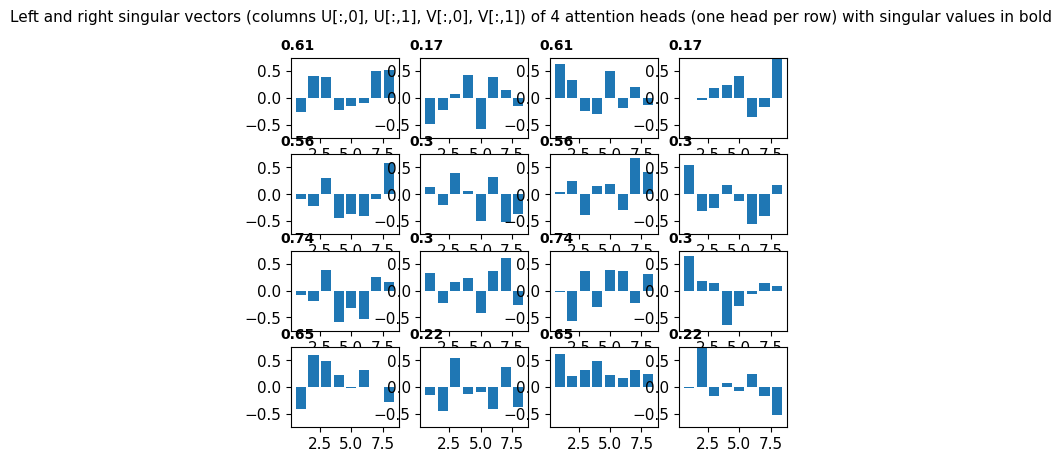

In [31]:
wq = in_proj_weight[:8,:].view(num_heads, filter_numbers[-1], filter_size)
wk = in_proj_weight[8:16:,:].view(num_heads, filter_numbers[-1], filter_size)
m = torch.matmul(wq, wk.transpose(1,2))

fig, ax = plt.subplots(4,4)
fig.suptitle("Left and right singular vectors (columns U[:,0], U[:,1], V[:,0], V[:,1]) of 4 attention heads (one head per row) with singular values in bold")
lower_lim = -0.75
upper_lim = 0.75
sv_pairs = torch.zeros((4,2,2,8))  # (heads, singular value index 0/1, type of singular vec left/right)
singular_values = torch.zeros((4,2))

for i in range(num_heads):
    head_weight_mtx = m[i,:,:]
    u,s,v = torch.svd(head_weight_mtx)
    singular_values[i,:] = s[:2]
    ax[i,0].bar(np.arange(1,9), u[:,0])
    ax[i,1].bar(np.arange(1,9), u[:,1])
    ax[i,2].bar(np.arange(1,9), v[:,0])
    ax[i,3].bar(np.arange(1,9), v[:,1])
    for svidx in [0,1]:
        sv_pairs[i,svidx,0,:] = u[:,svidx]
        sv_pairs[i,svidx,1,:] = v[:,svidx]
    for j in range(4):
        ax[i,j].set_ylim([lower_lim, upper_lim])
        svtext = str(np.round(s.numpy()[j%2],2))
        ax[i,j].text(-0.1, 1.1, svtext, transform=ax[i,j].transAxes, size=10, weight='bold')
        
# fig.savefig("weight-mtx-singular-vectors.png")

In [32]:
def cnn_block_wrapper_generator(normalization1, normalization2, do_relu, do_residual, do_padding, num_filters=8):
    # define model in eval mode
    cnn = CNN_Block(
        out_filters=num_filters,
        do_residual=do_residual,
        do_relu=do_relu,
        do_padding=do_padding,
        do_normalization1=normalization1,
        do_normalization2=normalization2,
    ).eval()
    # set weights
    with torch.no_grad():
        if num_filters == 8:
            cnn.conv1.weight = nn.Parameter(c1_8.cpu())
            cnn.conv1.bias = nn.Parameter(c1b_8.cpu())
            cnn.conv2.weight = nn.Parameter(c2_8.cpu())
            cnn.conv2.bias = nn.Parameter(c2b_8.cpu())
        else:
            raise Exception(f"Weights not defined for {num_filters} filters")
    # define function to be optimized
    def cnn_func_full(x):
        # make float tensor of shape [1,1,3] out of x, as this is the input the CNN requires
        x = torch.DoubleTensor(np.array(x, dtype=np.float32))
        x = x[None, None, :]
        x = x.float()
        with torch.no_grad():
            # use [1] to get second output, which does not have residual connection added (see CNN_Block)
            out = cnn(x)[1]
            # get last (in time) value of output for each convolutional filter, as this corresponds to
            # the full dot product of the 3-dim convolution and the 3-dim input for each channel
            out = out.detach().numpy()[0,:,-1]
            return out
    # return constructed function
    return cnn_func_full

In [ ]:
FULL_OUT = 0
ZERO_LOCI = {}
def optimize_input_patterns_full(func, full_target, num_outputs=8, input_dim=3, domain=(-1,1), trials=2500, 
                                 full_target_id=None):
    # For CNN_Block, num_outputs is number of convolutions, input_dim is receptive field of convolution
    output = np.zeros(input_dim)
    minf = 1e10
    minres = None
    
    def error(arg):
        global FULL_OUT
        FULL_OUT = func(arg) 
        return np.linalg.norm(func(arg) - full_target, 2)**2 / np.linalg.norm(full_target,2)**2
    
    for trial in tqdm(range(trials)):
        res = optimize.minimize(
            error,
            x0=np.random.randn(input_dim),
            tol=1e-10,
            bounds=[domain] * input_dim,
        )
        if res.fun <= minf:
            minf = res.fun
            minres = res
            minout = FULL_OUT
            if np.linalg.norm(minout,2) <= 1e-3:
                global ZERO_LOCI
                if full_target_id not in ZERO_LOCI:
                    ZERO_LOCI[full_target_id] = [(minf, minout, minres.x)]
                else:
                    ZERO_LOCI[full_target_id].append((minf, minout, minres.x))
        if trial % 5000 == 0:
            print(np.round(minf,4))
            print(np.round(minres.x,4))
            print(np.round(minout,4))
            print('----')
    print(minres)
    output = minres.x
    return output, minf, minout


targets = sv_pairs.numpy()

# Settings for searching for optimal patterns
CNN_FILTERS = 8
NORMALIZE1 = False
NORMALIZE2 = True
RELU = True
RESIDUAL = False
PADDING = False
INPUT_DIM = 3
DOMAIN = (-np.inf, np.inf)

cnn_func = cnn_block_wrapper_generator(
    do_residual=RESIDUAL,
    normalization1=NORMALIZE1,
    normalization2=NORMALIZE2,
    do_relu=RELU,
    do_padding=PADDING,
    num_filters=CNN_FILTERS,
)
patterns = np.zeros((CNN_FILTERS, INPUT_DIM))
errors = np.zeros(CNN_FILTERS)
outputs = np.zeros((CNN_FILTERS, CNN_FILTERS))
for i in range(CNN_FILTERS):
    print(f'============= PATTERN {i+1} =============')
    target = np.zeros(CNN_FILTERS)
    target[i] = 1
    patterns[i, :], errors[i], outputs[i, :] = optimize_input_patterns_full(
        cnn_func,
        num_outputs=CNN_FILTERS,
        input_dim=INPUT_DIM,
        domain=DOMAIN,
        full_target=target,
        trials=50000,
    )


============= PATTERN 1 =============


  0%|          | 18/50000 [00:00<04:42, 177.19it/s]

1.6819
[-0.6497  0.6486  0.9987]
[0.     0.5184 0.4967 0.     0.0958 0.3966 0.     0.    ]
----


 10%|█         | 5014/50000 [01:00<06:30, 115.11it/s]

0.3635
[-0.182  -0.3715 -0.2425]
[1.0488 0.3173 0.0642 0.     0.5062 0.     0.     0.    ]
----


...

0.8833
[-0.2688 -0.2405 -0.3138]
[0.     0.3375 0.     0.     0.1872 0.     0.5339 0.3297]
----


 90%|█████████ | 45005/50000 [09:29<00:45, 108.99it/s]

0.8833
[-0.2688 -0.2405 -0.3138]
[0.     0.3375 0.     0.     0.1872 0.     0.5339 0.3297]
----


100%|██████████| 50000/50000 [10:35<00:00, 78.70it/s] 

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.8785457746368524
        x: [-2.089e-02 -1.640e-02 -2.868e-02]
      nit: 26
      jac: [ 2.657e+01  2.815e+01  2.497e+01]
     nfev: 868
     njev: 217
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>


In [140]:
with open("plots/basis-patterns-50000-true.pkl", 'wb') as f:
    pickle.dump((patterns, outputs, errors, ZERO_LOCI), f)

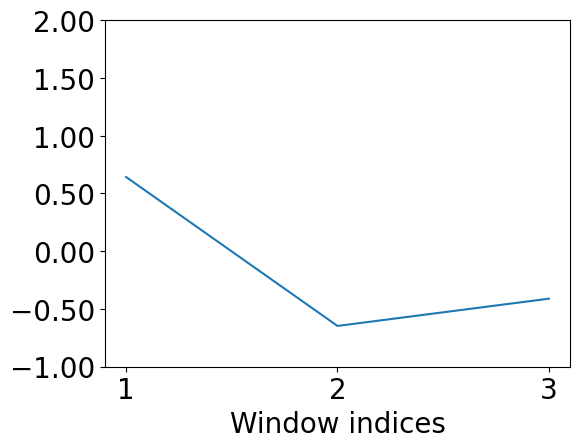

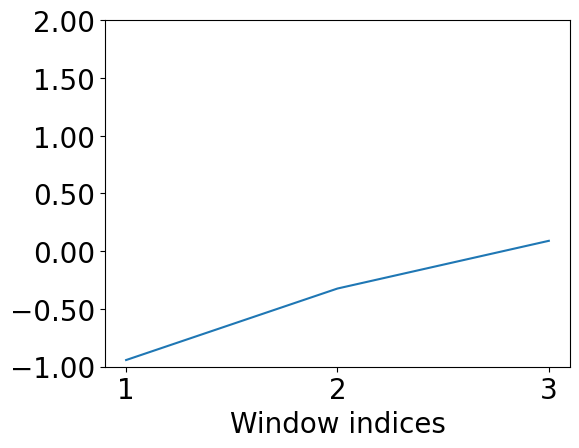

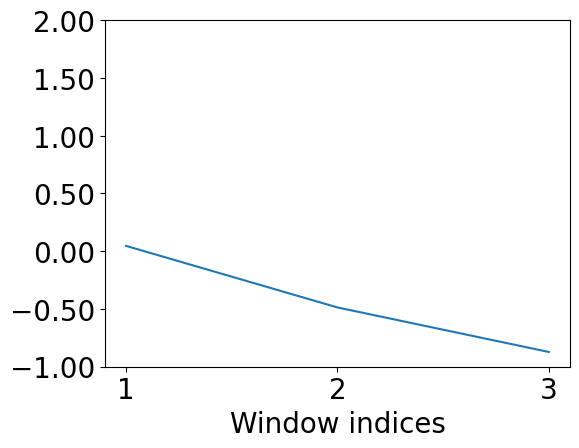

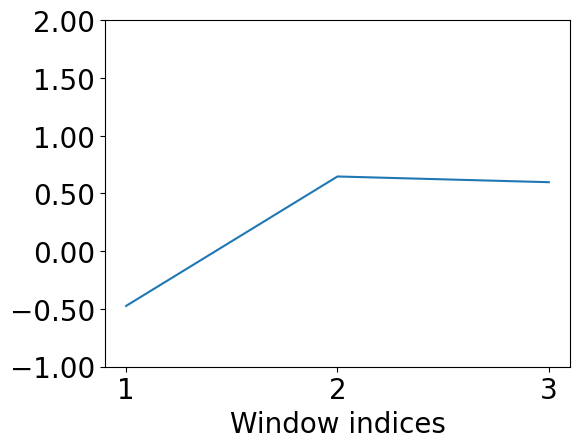

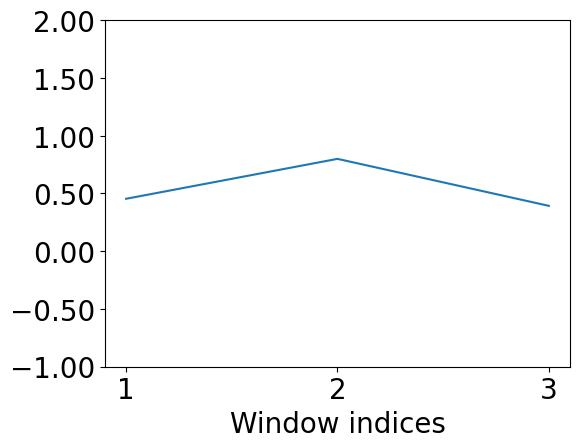

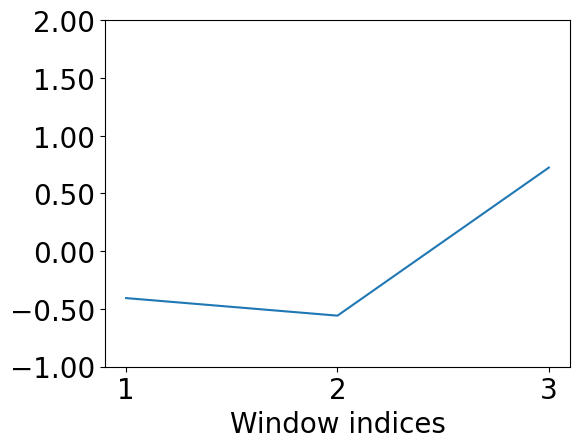

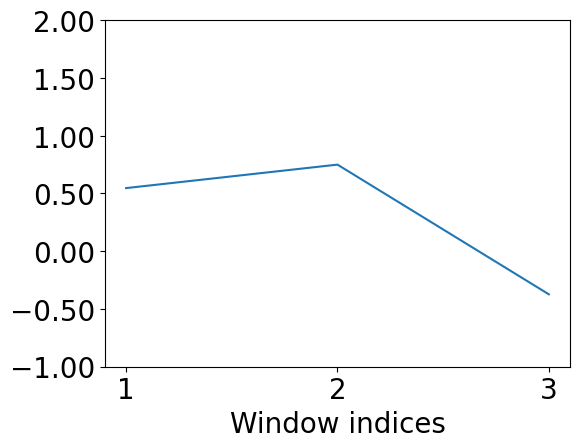

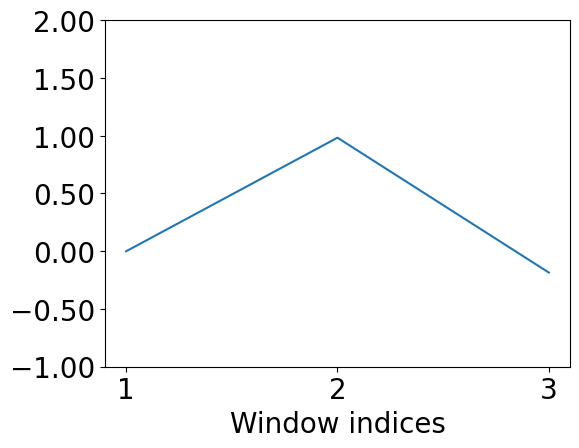

In [ ]:
SMALL_SIZE = 20
BIGGER_SIZE = 20

plt.rcParams['figure.figsize'] = 6,4.5
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=SMALL_SIZE)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize

patterns_plot = patterns.T / np.linalg.norm(patterns, axis=1)[:,None].T

for i in range(8):
    plt.plot(patterns_plot[:,i])
    plottitle = f"Basis pattern {i+1}"
    plotfilename = f"basis-pattern-{i+1}.png"
    plt.ylim([-1, 2])
    plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.2f}'))
    plt.xticks(ticks=[0,1,2], labels=[1,2,3], rotation = 0)
    plt.xlabel('Window indices')
    # plt.savefig('InterpretationPlots2/' + plotfilename, bbox_inches='tight')
    plt.show()

## Figure group: 17 and 18

### Data/model loading

In [33]:
# Hyperparameters
num_epochs = 100
learning_rate = 0.001
optimizer = 'Adam'
input_dim = 30
filter_size = 2
filter_numbers = [1,8,16,32]
num_conv_blocks = len(filter_numbers)-1
dropout = 1-0.75
attention_heads = 4
hidden_units = 2*filter_numbers[-1]
num_encoder_layers = 1


torch.set_default_dtype(torch.float)
torch.autograd.set_detect_anomaly(True)
torch.backends.cudnn.deterministic = False

class CNN_Block(nn.Module):
    def __init__(self, in_filters=16, out_filters=32, normalization=True, filter_size=2):
        super(CNN_Block, self).__init__()  
        self.in_filters = in_filters
        self.out_filters = out_filters
        
        self.conv1 = nn.Conv1d(in_channels=in_filters, out_channels=out_filters, kernel_size=filter_size,
                                    stride=1, padding=0, dilation=1, groups=1, bias=True, padding_mode='zeros')
        self.conv2 = nn.Conv1d(in_channels=out_filters, out_channels=out_filters, kernel_size=filter_size,
                                    stride=1, padding=0, dilation=1, groups=1, bias=True, padding_mode='zeros')
        self.relu = nn.ReLU(inplace=True)
        self.left_zero_padding = nn.ConstantPad1d((filter_size-1,0),0)
        
        self.normalization1 = nn.InstanceNorm1d(in_filters)
        self.normalization2 = nn.InstanceNorm1d(out_filters)
        self.normalization = normalization
       
    def forward(self, x):  # x and out have dims (N,C,T) where C is the number of channels/filters
        if self.normalization:
            out = self.normalization1(x)
        out = self.left_zero_padding(out)
        out = self.conv1(out)
        out = self.relu(out)
        out = self.left_zero_padding(out)
        if self.normalization: 
            out = self.normalization2(out)
        out = self.conv2(out)
        out = self.relu(out)
        out1 = out + x.repeat(1,int(self.out_filters/self.in_filters),1)   
        return out1,out 
    

class CNN_Transformer(nn.Module):
    def __init__(
        self,
        random_seed=0,
        device="cpu",  # other options for device are eg "cuda:6"
        normalizationConv=True,
        filter_numbers=filter_numbers,
        attention_heads=attention_heads,
        useConvolution=True,
        hidden_units=hidden_units,
        dropout=dropout,
        filter_size=filter_size,
        useTransformer=True,
    ):
        super(CNN_Transformer, self).__init__()
        self.random_seed = random_seed 
        torch.manual_seed(self.random_seed)
        self.device = torch.device(device)
        self.filter_numbers = filter_numbers
        self.useTransformer = useTransformer
        self.useConvolution = (useConvolution and len(filter_numbers)>0)
        
        self.convBlocks = nn.ModuleList()
        for i in range(len(filter_numbers)-1):
            self.convBlocks.append(
                CNN_Block(filter_numbers[i],filter_numbers[i+1],normalization=normalizationConv,filter_size=filter_size))
        self.encoder = nn.TransformerEncoderLayer(d_model=filter_numbers[-1], nhead=attention_heads, dim_feedforward=hidden_units,dropout=dropout)
        self.linear = nn.Linear(filter_numbers[-1],1)
                 
    def forward(self,x):  # x has dimension (N,T)
        N,T = x.shape
        x = x.reshape((N,1,T))  # (N,1,T)
        logging.info("pre-conv", x.size())
        if self.useConvolution:
            for i in range(len(self.filter_numbers)-1):
                x = self.convBlocks[i](x)[0]  # (N,C,T), C is the number of channels/features
                logging.info("convBlock", i, x.size())
        x = x.permute(2,0,1)
        logging.info("post-permute", x.size())
        if self.useTransformer:
            x = self.encoder(x)  # the input of the transformer is (T,N,C)
            logging.info("post-transformer", x.size())
        return self.linear(x[-1,:,:]).squeeze()  # this outputs the weights #self.softmax(x[-1,:,:]) #(N,num_classes)
    
class WindowsDataset(Dataset):
    def __init__(self,Data,lookback):
        assetsToConsider = np.count_nonzero(Data,axis=0)>=lookback  # chooses assets which have at least #lookback non-missing observations in all the training time
        self.data = Data[:,assetsToConsider]
        T,N = self.data.shape
        cumsums = np.cumsum(self.data,axis=0)
        self.windows = np.zeros((T-lookback,N,lookback))
        self.idxsSelected = np.zeros((T-lookback,N),dtype=bool)
        for t in range(lookback,T):
            self.idxsSelected[t-lookback,:] = ~np.any(self.data[(t-lookback):t,:] == 0, axis = 0).ravel()  # chooses assets which have no missing returns in the t-th lookback window
            idxs = self.idxsSelected[t-lookback,:]
            if t == lookback:
                self.windows[t-lookback,idxs,:] = cumsums[t-lookback:t,idxs].T
            else:
                self.windows[t-lookback,idxs,:] = cumsums[t-lookback:t,idxs].T-cumsums[t-lookback-1,idxs].reshape(int(sum(idxs)),1)
    
        self.numberTimes = T
        self.numberAssets = N
        self.lookback = lookback
        
    def __getitem__(self,t):
        return torch.tensor(self.windows[t])
        
    def __len__(self):
        return self.numberTimes

In [34]:
def linear(Input, weight, bias=None):
    if Input.dim() == 2 and bias is not None:
        # fused op is marginally faster
        ret = torch.addmm(bias, Input, weight.t())
    else:
        output = Input.matmul(weight.t())
        if bias is not None:
            output += bias
        ret = output
    return ret

def softmax(Input, dim=None, dtype=None):
    if dtype is None:
        ret = Input.softmax(dim)
    else:
        ret = Input.softmax(dim, dtype=dtype)
    return ret

def moving_average(a, n=30, axis=1):
    # creates a simple moving average for the matrix a, with a window size of n, along the given axis
    ret = np.cumsum(a,axis)
    N = a.shape[axis]
    if axis == 0:
        ret[n:] = ret[n:] - ret[:-n]  # np.take(ret, range(n,N), axis=axis) - np.take(ret, range(0,N-n), axis=axis, out = )
        try:
            ret[:n - 1] = ret[:n-1] / np.linspace(1,min(n-1,N),min(n-1, N))
        except:
            ret[:n - 1] = ret[:n-1] / np.linspace(1,min(n-1,N),min(n-1, N)).reshape((min(n-1,N),1))
        ret[n - 1:] = ret[n - 1:] / n
    elif axis == 1:
        ret[:,n:] = ret[:,n:] - ret[:,:-n]  # np.take(ret, range(n,N), axis=axis) - np.take(ret, range(0,N-n), axis=axis, out = )
        ret[:,:n - 1] = ret[:,:n-1] / np.linspace(1,min(n-1,N),min(n-1, N)).reshape((min(n-1,N),1))
        ret[:,n - 1:] = ret[:,n - 1:] / n
    else:
        raise Exception(f"Invalid axis for moving average '{axis}'")
    return ret


lookback = 30
T = 2769 + lookback
indices = [0]
ticklabels = [str(DailyDates[-(T-lookback)].year)]
for i in range(T-lookback-1):
    if DailyDates[-(T-lookback):][i].year != DailyDates[-(T-lookback):][i+1].year:
        indices += [i]
        ticklabels += [str(DailyDates[-(T-lookback):][i+1].year)]
indices += [T-lookback-1]
ticklabels += ['2017']

print(indices, ticklabels)
print(DailyDates[-(T-lookback):][-1].strftime('%Y-%m-%d'))

sample_permnos = (np.count_nonzero(residuals[2012:],axis=0)==(4781-2012))

[0, 250, 501, 754, 1006, 1258, 1510, 1760, 2012, 2264, 2516, 2768] ['2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017']
2016-12-30


In [43]:
normalizationConv = True
filter_numbers = [1,8]
dropout = 0.25
attention_heads = 4
hidden_units = 16
filter_size = 2
useTransformer = True
device = 'cpu'
lookback = 30


model = CNN_Transformer(
    random_seed=0,
    device="cpu",
    normalizationConv=normalizationConv,
    filter_numbers=filter_numbers,
    attention_heads=attention_heads,
    useConvolution=True,
    hidden_units=hidden_units,
    dropout=dropout,
    filter_size=filter_size,
    useTransformer=useTransformer
)

# load model
def load_model(path):
    # format of saved .tar file is a dictionary with:
    # checkpoint = {
    #     'epoch': epoch,
    #     'model_state_dict': model.state_dict(),
    #     'optimizer_state_dict': optimizer.state_dict(),
    #     'loss': loss}
    checkpoint = torch.load(path)
    from collections import OrderedDict
    state_dict = checkpoint['model_state_dict']
    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        print(f'loading {k}')  #, norm: {np.linalg.norm(v.cpu().numpy())}')
        name = k[7:] # remove `module.`
        new_state_dict[name] = v
    model.load_state_dict(new_state_dict)
    model.eval()
    return model

model_path = 'saved-results/cnn_transformer/Checkpoint-0_seed_IPCA5_0transCost_0holdCost_residualWeights_SharpeNoRetrain_normalized_CNNTransformer_30lookback_2012lengthTraining_[1, 8]filters_4attention_0.25dropout_16hiddenunits_recalibration0.tar'
model = load_model(model_path)

/tmp/ipykernel_186290/43155813.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path)


loading module.convBlocks.0.conv1.weight
loading module.convBlocks.0.conv1.bias
loading module.convBlocks.0.conv2.weight
loading module.convBlocks.0.conv2.bias
loading module.encoder.self_attn.in_proj_weight
loading module.encoder.self_attn.in_proj_bias
loading module.encoder.self_attn.out_proj.weight
loading module.encoder.self_attn.out_proj.bias
loading module.encoder.linear1.weight
loading module.encoder.linear1.bias
loading module.encoder.linear2.weight
loading module.encoder.linear2.bias
loading module.encoder.norm1.weight
loading module.encoder.norm1.bias
loading module.encoder.norm2.weight
loading module.encoder.norm2.bias
loading module.linear.weight
loading module.linear.bias


### Attention and allocation weights over all time (Figure 18)

/tmp/ipykernel_186290/1272512858.py:41: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  states[i,t-lookback] = z1[:,0,:].cpu()
/tmp/ipykernel_186290/1272512858.py:42: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  convNoRes[i,t-lookback] = z0[:,0,:].cpu()
/tmp/ipykernel_186290/1272512858.py:75: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  statesTrans[i,t-lookback,:] = z[:,0,:].cpu()


Weights of the convolutional layers


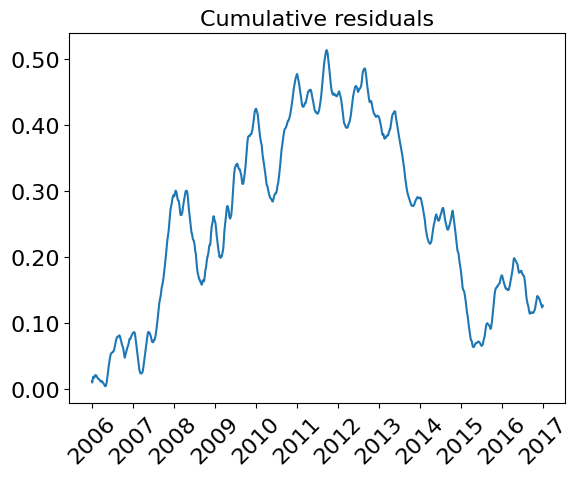

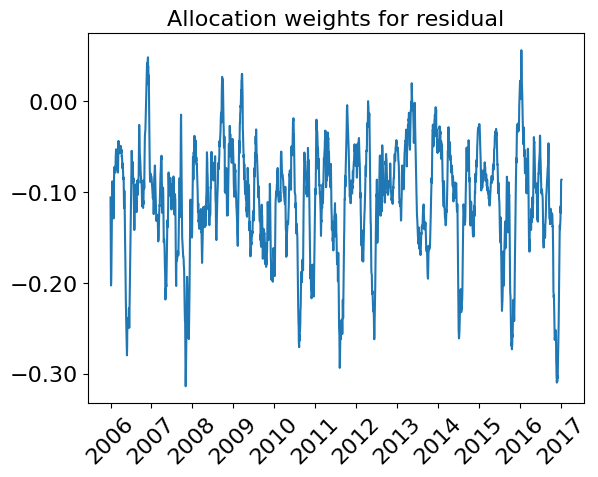

(2769, 30)


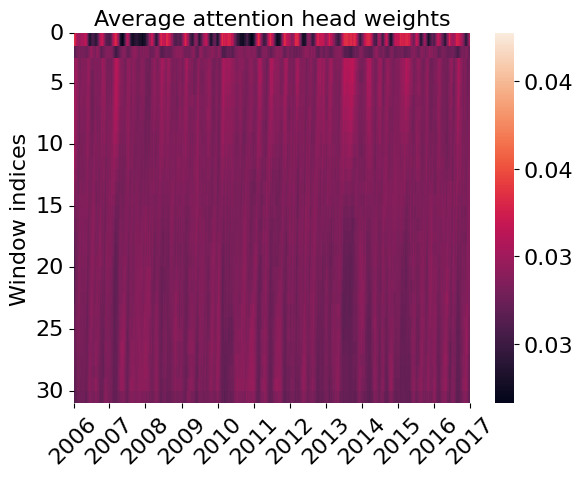

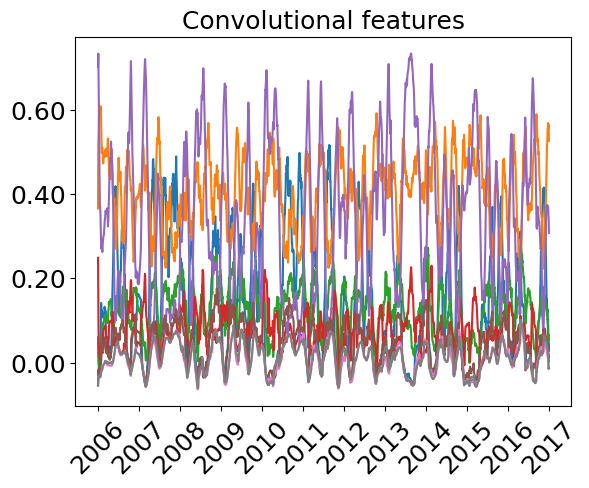

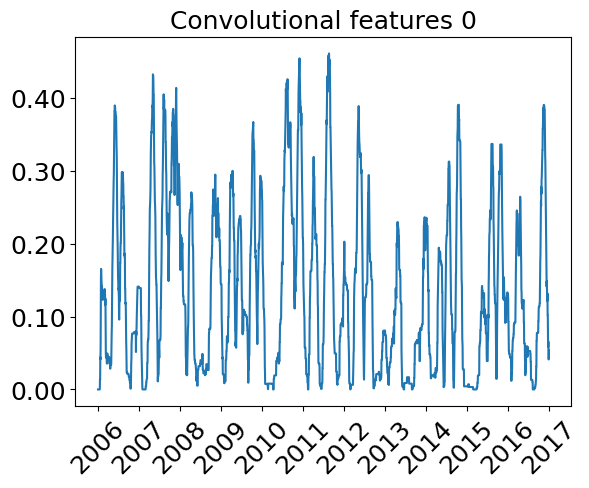

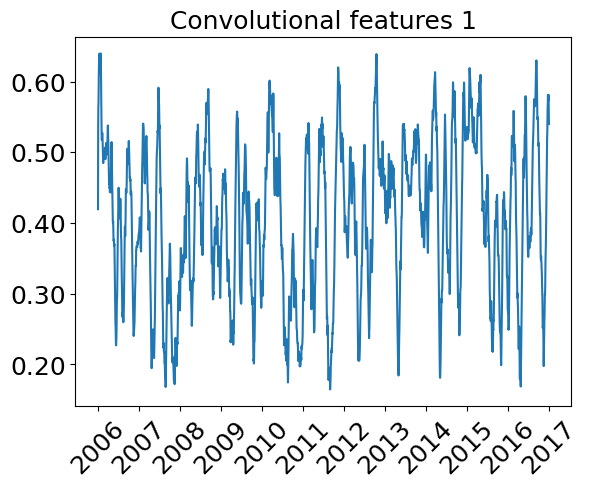

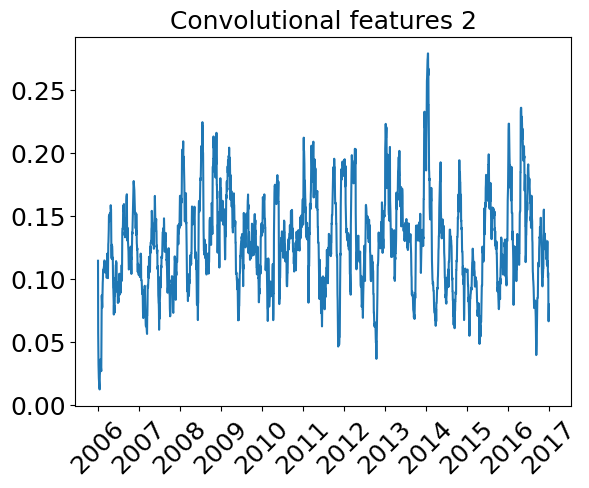

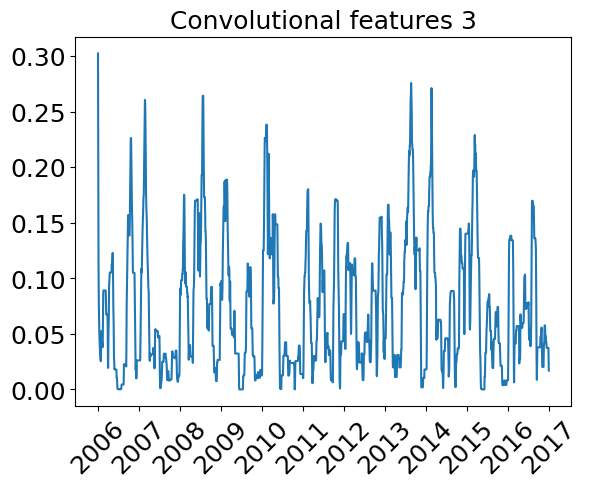

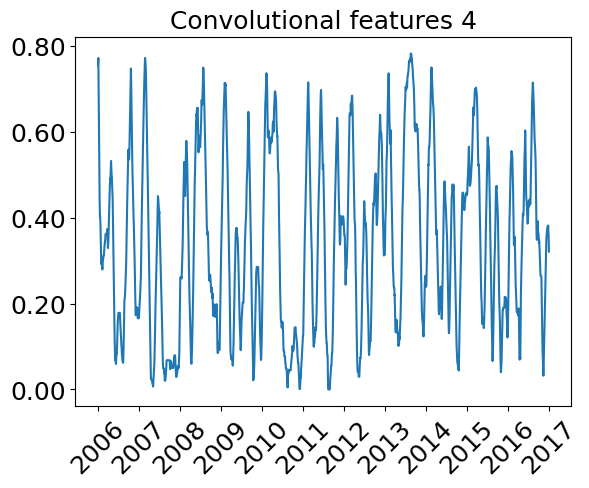

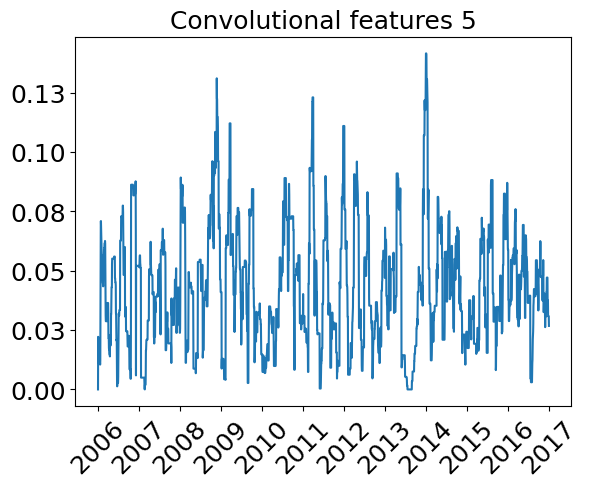

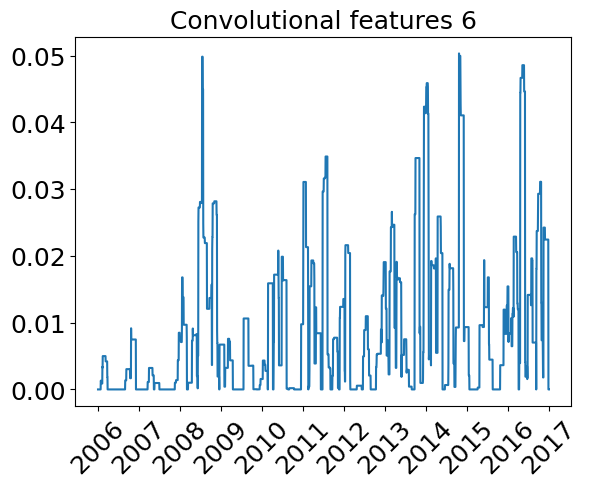

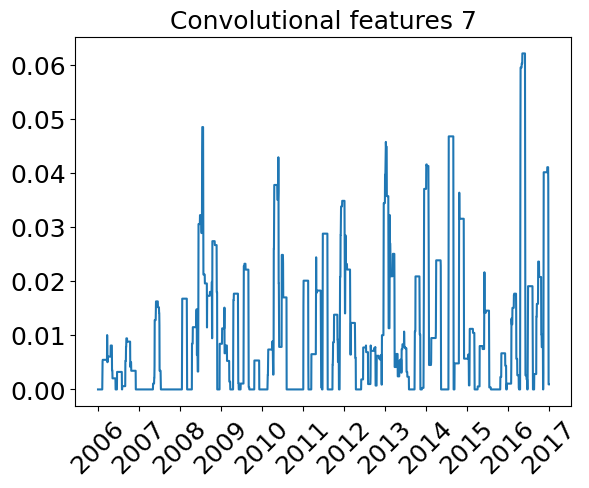

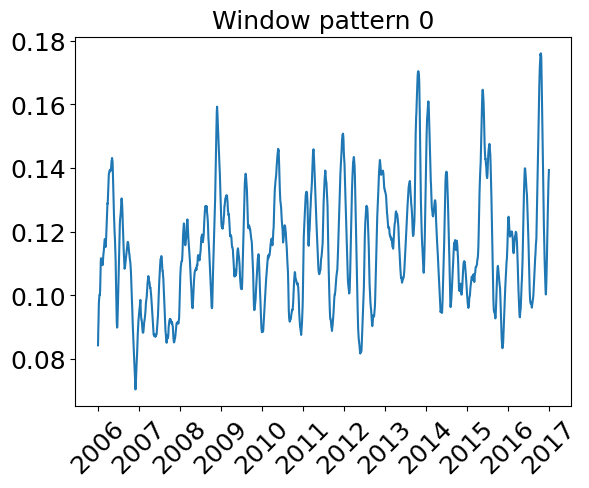

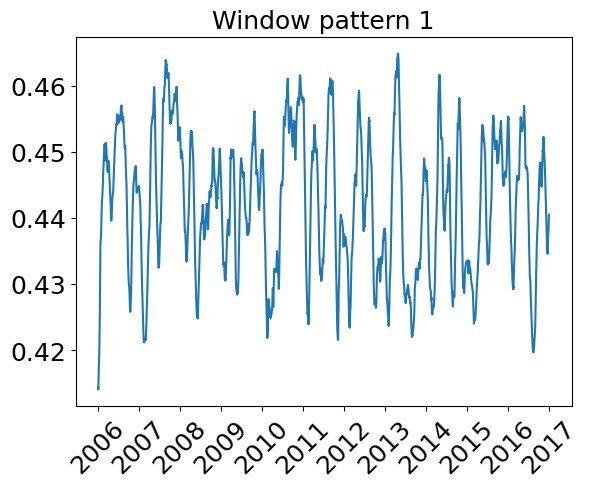

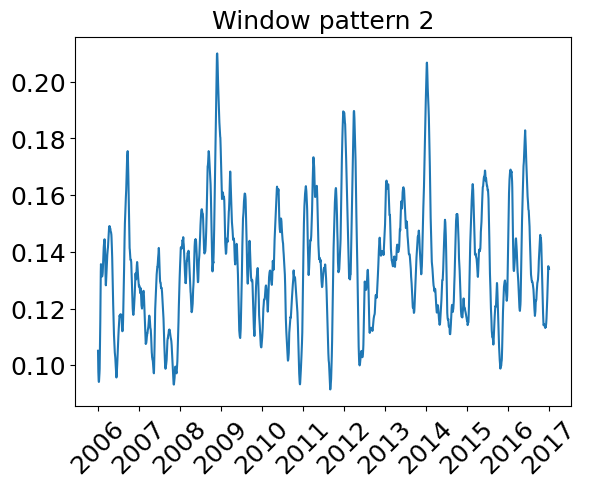

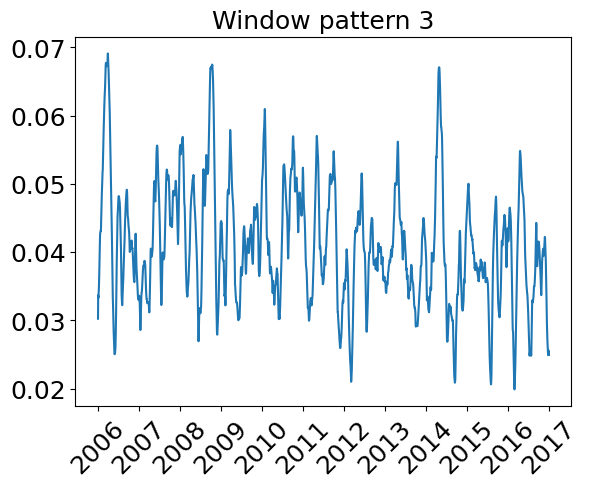

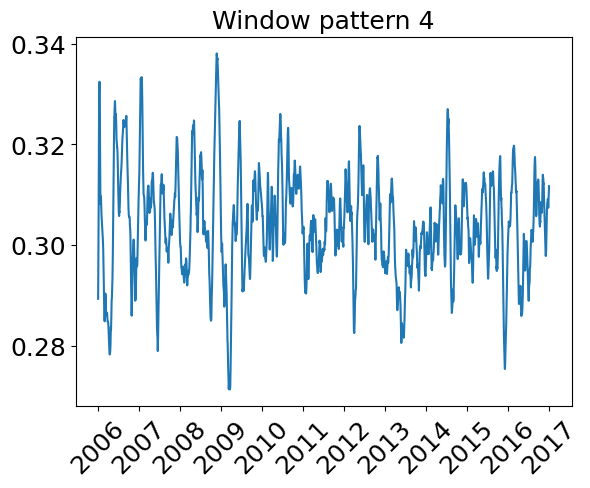

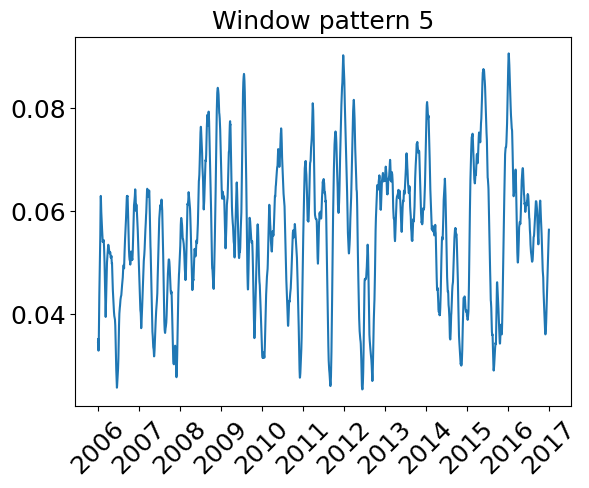

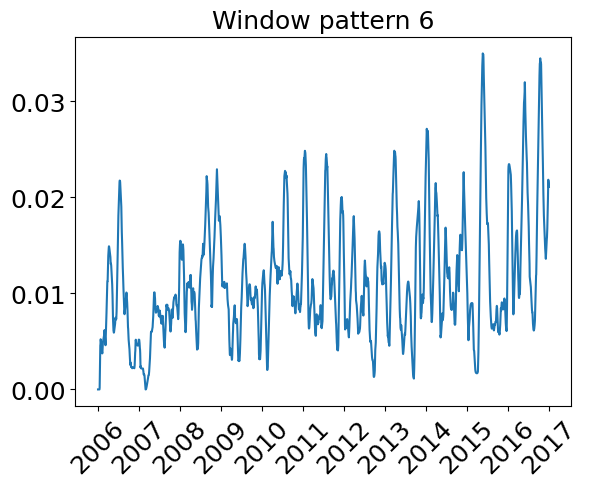

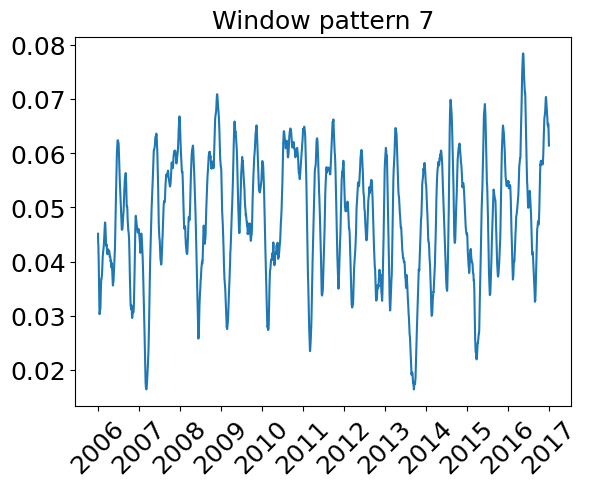

(2769, 30)


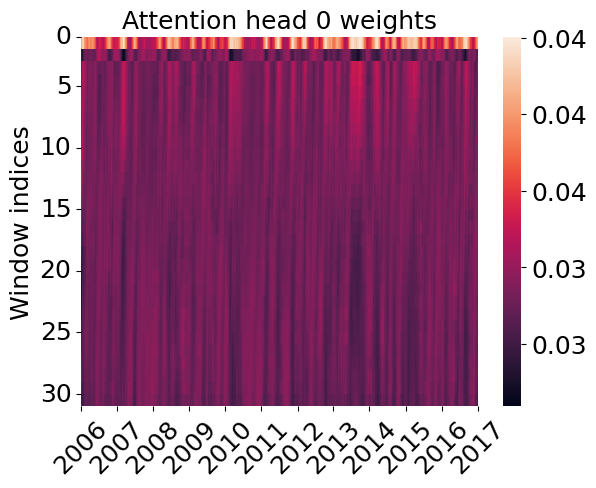

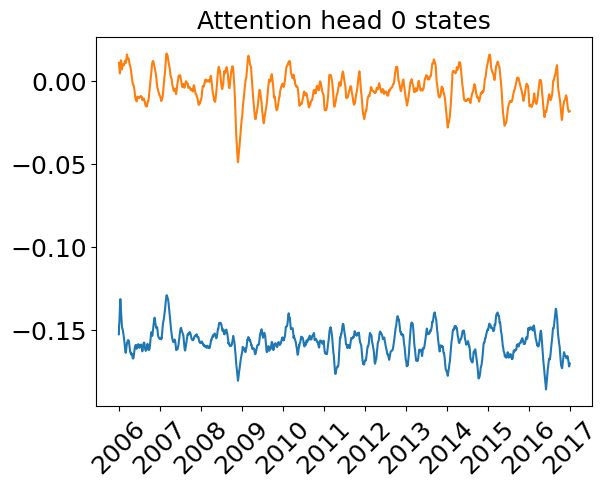

/tmp/ipykernel_186290/1272512858.py:239: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  plt.plot_date(DailyDates[-(T-lookback):],conv_states_projected[i,:T-lookback,j,-1,l], label=f'{l}', marker='None',linestyle='solid')
/tmp/ipykernel_186290/1272512858.py:239: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.plot_date(DailyDates[-(T-lookback):],conv_states_projected[i,:T-lookback,j,-1,l], label=f'{l}', marker='None',linestyle='solid')
/tmp/ipykernel_186290/1272512858.py:239: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  plt.plot_date(DailyDates[-(T-lookback):],conv_states_projected[i,:T-lookback,j,-1,l], label=f'{l}', marker='None',linestyle='solid')
/tmp/ipykernel_186290/1272512858.py:239: UserWa

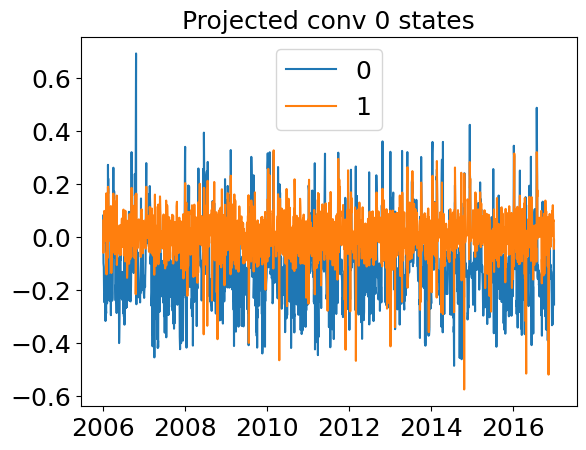

(2769, 30)


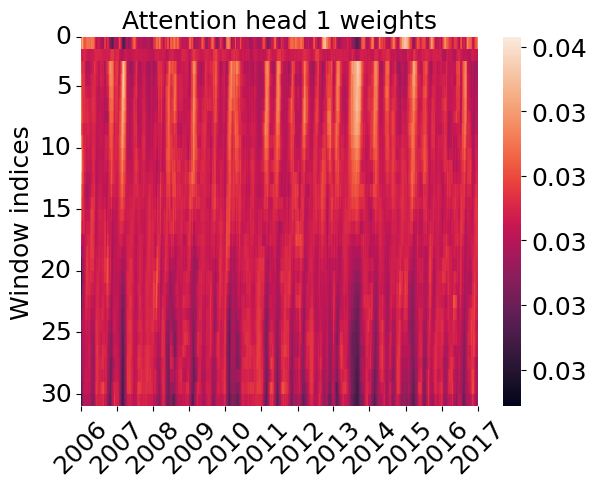

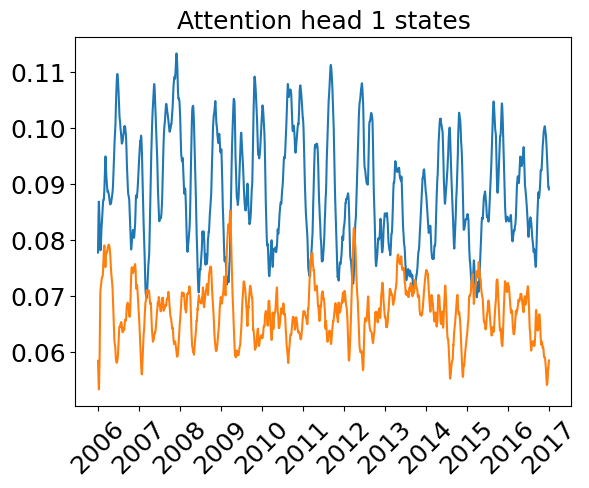

/tmp/ipykernel_186290/1272512858.py:239: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  plt.plot_date(DailyDates[-(T-lookback):],conv_states_projected[i,:T-lookback,j,-1,l], label=f'{l}', marker='None',linestyle='solid')
/tmp/ipykernel_186290/1272512858.py:239: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.plot_date(DailyDates[-(T-lookback):],conv_states_projected[i,:T-lookback,j,-1,l], label=f'{l}', marker='None',linestyle='solid')
/tmp/ipykernel_186290/1272512858.py:239: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  plt.plot_date(DailyDates[-(T-lookback):],conv_states_projected[i,:T-lookback,j,-1,l], label=f'{l}', marker='None',linestyle='solid')
/tmp/ipykernel_186290/1272512858.py:239: UserWa

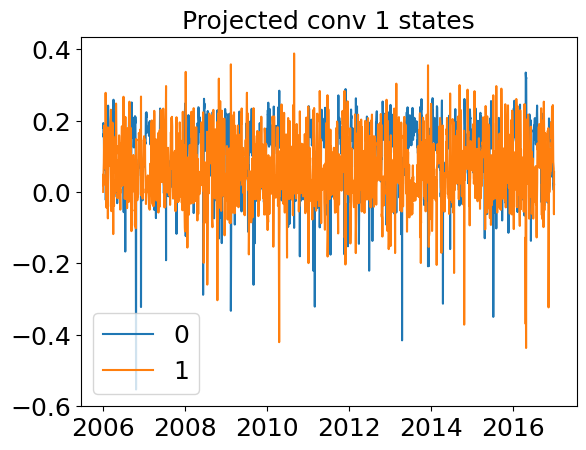

(2769, 30)


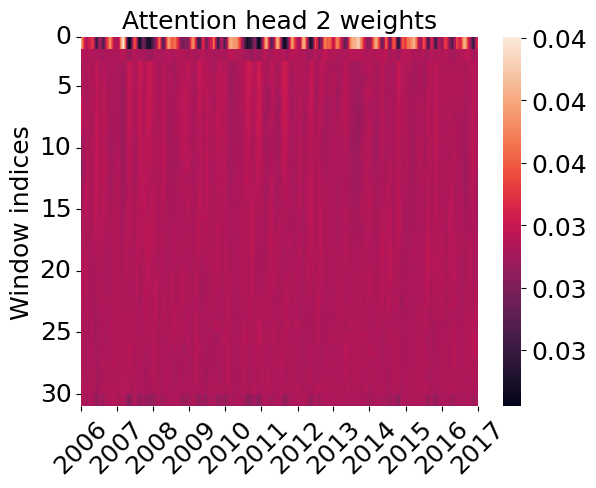

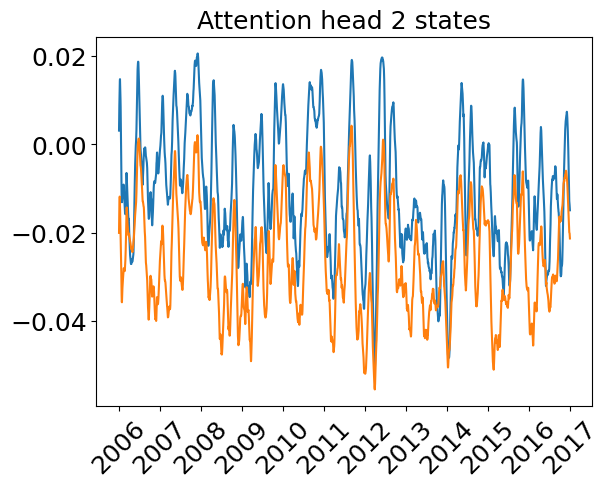

/tmp/ipykernel_186290/1272512858.py:239: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  plt.plot_date(DailyDates[-(T-lookback):],conv_states_projected[i,:T-lookback,j,-1,l], label=f'{l}', marker='None',linestyle='solid')
/tmp/ipykernel_186290/1272512858.py:239: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.plot_date(DailyDates[-(T-lookback):],conv_states_projected[i,:T-lookback,j,-1,l], label=f'{l}', marker='None',linestyle='solid')
/tmp/ipykernel_186290/1272512858.py:239: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  plt.plot_date(DailyDates[-(T-lookback):],conv_states_projected[i,:T-lookback,j,-1,l], label=f'{l}', marker='None',linestyle='solid')
/tmp/ipykernel_186290/1272512858.py:239: UserWa

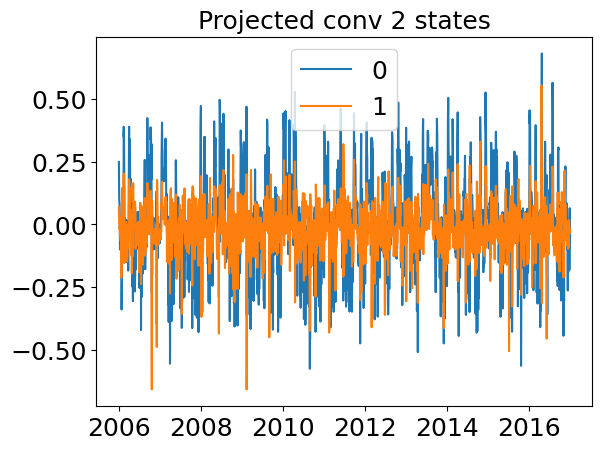

(2769, 30)


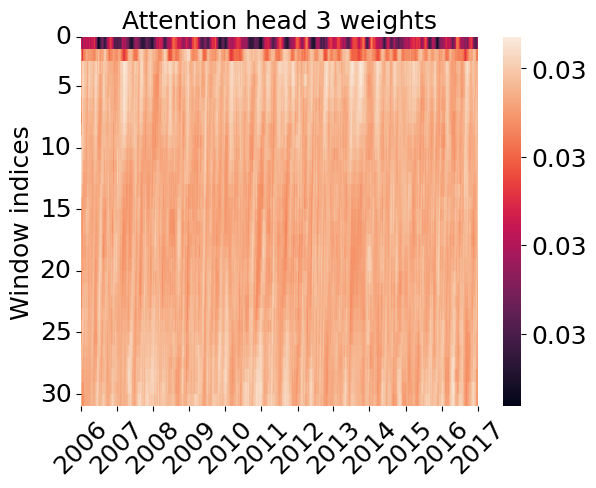

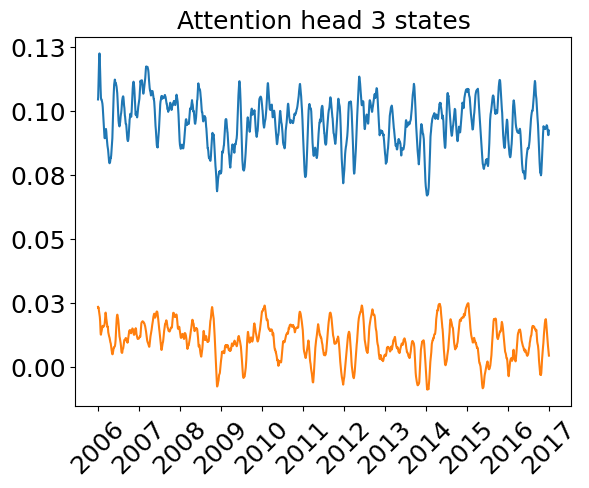

/tmp/ipykernel_186290/1272512858.py:239: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  plt.plot_date(DailyDates[-(T-lookback):],conv_states_projected[i,:T-lookback,j,-1,l], label=f'{l}', marker='None',linestyle='solid')
/tmp/ipykernel_186290/1272512858.py:239: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.plot_date(DailyDates[-(T-lookback):],conv_states_projected[i,:T-lookback,j,-1,l], label=f'{l}', marker='None',linestyle='solid')
/tmp/ipykernel_186290/1272512858.py:239: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  plt.plot_date(DailyDates[-(T-lookback):],conv_states_projected[i,:T-lookback,j,-1,l], label=f'{l}', marker='None',linestyle='solid')
/tmp/ipykernel_186290/1272512858.py:239: UserWa

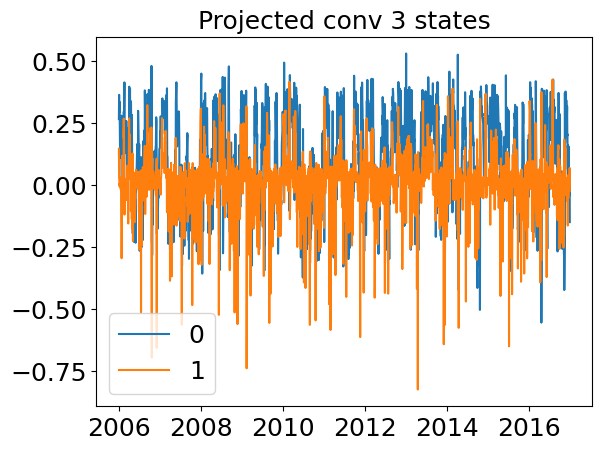

/tmp/ipykernel_186290/1272512858.py:246: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  plt.plot_date(DailyDates[-(T-lookback):],attention_final_states[i,:T-lookback,-1,l], label=f'{l}', marker='None',linestyle='solid')
/tmp/ipykernel_186290/1272512858.py:246: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.plot_date(DailyDates[-(T-lookback):],attention_final_states[i,:T-lookback,-1,l], label=f'{l}', marker='None',linestyle='solid')
/tmp/ipykernel_186290/1272512858.py:246: MatplotlibDeprecationWarning: The plot_date function was deprecated in Matplotlib 3.9 and will be removed in 3.11. Use plot instead.
  plt.plot_date(DailyDates[-(T-lookback):],attention_final_states[i,:T-lookback,-1,l], label=f'{l}', marker='None',linestyle='solid')
/tmp/ipykernel_186290/1272512858.py:246: UserWarni

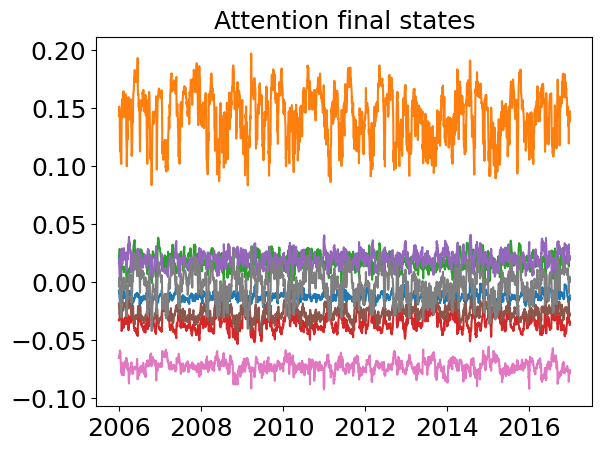

In [37]:
device = torch.device('cuda')
lookback = 30
parallelize=False
num_heads = 4
T = 2769+lookback
filter_numbers = [1,8]

windows = np.zeros((1,T-lookback,lookback))
states = np.zeros((1,T-lookback,lookback,filter_numbers[-1]))
convNoRes = np.zeros((1,T-lookback,lookback,filter_numbers[-1]))
conv_states_projected = np.zeros((1,T-lookback,num_heads,lookback,filter_numbers[-1]//num_heads))
statesTrans = np.zeros((1,T-lookback,lookback,filter_numbers[-1]))
attention_head_states = np.zeros((1,T-lookback,num_heads,lookback,filter_numbers[-1]//num_heads))
attention_weights = np.zeros((1,T-lookback,num_heads,lookback))
attention_final_states = np.zeros((1,T-lookback,lookback,filter_numbers[-1]))
weights = np.zeros((1,T-lookback))
windowPattern = np.zeros((1,T-lookback,filter_numbers[-1]))
averageAttentionWeights = np.zeros((1,T-lookback,lookback))
 

i = 0
model = model
Data = residuals.copy()
n = np.where(sample_permnos)[0][6]
x = Data[-T:,n:n+1] 
model.to(device)
model.eval()
T,N = x.shape

with torch.no_grad():
    for t in range(lookback,x.shape[0]):
        # idxsSelected = ~np.any(x[(t-lookback):t,:] == 0, axis = 0).ravel() 
        y = np.cumsum(x[(t-lookback):t,0],axis=0).T #(N,T)
        windows[i,t-lookback] = y.squeeze()
        z = torch.tensor(y,device=device, dtype = torch.float) 
        z = z.reshape((1,1,lookback))  #(N,1,T)
        for i in range(len(filter_numbers)-1):
            z1,z0 = model.module.convBlocks[i](z) if parallelize else model.convBlocks[i](z)
        z1 = z1.permute(2,0,1)  # the input of the transformer is (T,N,C)
        z0 = z0.permute(2,0,1)
        states[i,t-lookback] = z1[:,0,:].cpu()
        convNoRes[i,t-lookback] = z0[:,0,:].cpu()
        trans = model.module.useTransformer if parallelize else model.useTransformer
        if trans:
            transf = model.module.encoder if parallelize else model.encoder
            attention = transf.self_attn(z1,z1,z1)
            # print(attention[0].shape,attention[1].shape)
            in_proj_weight = transf.self_attn.in_proj_weight 
            in_proj_bias = transf.self_attn.in_proj_bias
            out_proj_weight = transf.self_attn.out_proj.weight
            out_proj_bias = transf.self_attn.out_proj.bias
            query = z1
            tgt_len = lookback
            src_len = lookback
            tgt_len, bsz, embed_dim = query.shape  # (lookback, N,filters)
            head_dim = embed_dim // num_heads
            q, k, v = linear(query, in_proj_weight, in_proj_bias).chunk(3, dim=-1)
            q = q.contiguous().view(tgt_len, bsz * num_heads, head_dim).transpose(0, 1)
            k = k.contiguous().view(-1, bsz * num_heads, head_dim).transpose(0, 1)
            v = v.contiguous().view(-1, bsz * num_heads, head_dim).transpose(0, 1)
            attn_output_weights = torch.bmm(q, k.transpose(1, 2))
            attn_output_weights = softmax(attn_output_weights, dim=-1)
            attn_output = torch.bmm(attn_output_weights, v)
            # print(attn_output.shape) #(num_head,lookback,head_dim)
            attn_output2 = attn_output.transpose(0, 1).contiguous().view(tgt_len, bsz, embed_dim)
            attn_output2 = linear(attn_output2, out_proj_weight, out_proj_bias)
            attn_output_weights = attn_output_weights.view(bsz, num_heads, tgt_len, src_len)
            
            conv_states_projected[i,t-lookback] = v.cpu().numpy()
            attention_weights[i,t-lookback] = attn_output_weights[0,:,-1].cpu().numpy()
            attention_head_states[i,t-lookback] = attn_output.cpu().numpy()
            attention_final_states[i,t-lookback] = attn_output2[:,0].cpu().numpy()
            # print(np.linalg.norm(attention[0][-1,0,:].cpu().numpy()-attn_output2[-1,0].cpu().numpy()))
            z = transf(z1)
            statesTrans[i,t-lookback,:] = z[:,0,:].cpu()
        weights[i,t-lookback] = model.linear(z[-1,0,:]).squeeze().cpu().numpy()

    averageAttentionWeights = np.mean(attention_weights,axis=2)
    # print(averageAttentionWeights.shape,convNoRes.shape)
    windowPattern = np.sum(np.expand_dims(averageAttentionWeights,axis=3)*convNoRes,axis=2)
    # print(windowPattern.shape)

if parallelize: 
    model = model.module

# Weights of the convolutions
print("Weights of the convolutional layers")
for l in range(len(filter_numbers)-1):
    block = model.convBlocks[l]
    # print(block.conv1.weight.data,block.conv1.bias.data)
    # print(block.conv2.weight.data,block.conv2.bias.data)

# Weights of the transformer
if model.useTransformer:
    transformer = model.encoder
    # print("Weights to project into attention heads")
    attention_heads = transformer.self_attn
    # print(attention_heads.in_proj_weight,attention_heads.in_proj_bias)  # this is [W^q,Q^k,W^v] (3*d_model,d_model)
    # print("Weights to combine the attention heads")
    # print(attention_heads.out_proj.weight, attention_heads.out_proj.bias)  # (this is W^O (d_model,d_model)

    # print("Weights of the transformer linear layers")
    # print(transformer.linear1.weight.data,transformer.linear1.bias.data)
    # print(transformer.linear2.weight.data,transformer.linear2.bias.data)

# Print data of linear layer corresponding to states
# print("Weights of the linear layer from states to weights")
# print(model.linear.weight.data,model.linear.bias.data)

SMALL_SIZE = 16
BIGGER_SIZE = 16

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=SMALL_SIZE)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize

# Plot of cumulative residuals
plt.figure()
# plt.plot_date(DailyDates[-(T-lookback):],moving_average(np.cumsum(x[lookback:T,0]),axis=0), marker='None',linestyle='solid')
plt.plot(range(T-lookback),moving_average(np.cumsum(x[lookback:T,0]),axis=0))
plt.title('Cumulative residual')
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.2f}'))
plt.xticks(ticks=indices, labels=ticklabels, rotation = 45)
# plt.savefig('InterpretationPlots/'+"CumRes.png",bbox_inches='tight')
plt.show()

plt.figure()
# plt.plot_date(DailyDates[-(T-lookback):],moving_average(weights[i,:T-lookback],axis=0),marker='None',linestyle='solid')
plt.plot(range(T-lookback),moving_average(weights[i,:T-lookback],axis=0))
plt.title('Allocation weights for residual')
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.2f}'))
plt.xticks(ticks=indices, labels=ticklabels, rotation = 45)
# plt.savefig('InterpretationPlots/'+f"Allocation.png",bbox_inches='tight')
plt.show()
plt.figure()

DFattentionWeights = pd.DataFrame(moving_average(averageAttentionWeights[i,:T-lookback,:],axis=0),index=DailyDates[-(T-lookback):].strftime('%Y'))
print(DFattentionWeights.shape)
ax = sns.heatmap(DFattentionWeights.T, fmt=".1f", yticklabels=[0,5,10,15,20,25,30], cbar_kws={'format': '%.2f'}, vmax=DFattentionWeights.max().max() * 1.1)  #,'ticks': [0,0.01,0.02,0.03,0.04,0.05]},vmin=0)#, vmax =0.04)
ax.set_yticks(np.linspace(0, 30 - 1, 7, dtype=np.int32))
ax.set_yticklabels([0,5,10,15,20,25,30])
ax.set_xticks(indices)
ax.set_xticklabels(ticklabels, rotation=45)
# sns.heatmap(DFattentionWeights.T)#, vmax = 0.1)#+0.15*(j))
# plt.legend()
plt.ylabel("Window indices")
plt.title('Average attention head weights')
# plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.2f}'))
# plt.savefig('InterpretationPlots/'+f"AverageAttentionWeights.png",bbox_inches='tight')
plt.show()

SMALL_SIZE = 18
BIGGER_SIZE = 18

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=SMALL_SIZE)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize


# Plots of some convolutional hidden states
plt.figure()
for qk in range(8):
    # plt.figure()
    # plt.plot_date(DailyDates[-(T-lookback):],moving_average(states[i,:T-lookback,-1,qk],axis=0), label=f'{l}', marker='None',linestyle='solid')
    plt.plot(range(T-lookback),moving_average(states[i,:T-lookback,-1,qk],axis=0))
    # for l in range(qk,qk+1):
    #     #plt.plot(range(T-lookback),states[i,:T-lookback,-1,l], label=f'{l}')
    #     plt.plot_date(DailyDates[-(T-lookback):],moving_average(states[i,:T-lookback,-1,l],axis=0), label=f'{l}', marker='None',linestyle='solid')
    # plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.2f}'))
    # plt.savefig('InterpretationPlots/'+f"ConvFeatures{qk}.png",bbox_inches='tight')
plt.title('Convolutional features')
plt.xticks(ticks=indices, labels=ticklabels, rotation = 45)
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.2f}'))
# plt.savefig('InterpretationPlots/'+f"ConvFeatures{'0and6'}.png",bbox_inches='tight')
plt.show()


for qk in range(8):
    plt.figure()
    # plt.figure()
    # plt.plot_date(DailyDates[-(T-lookback):],moving_average(states[i,:T-lookback,-1,qk],axis=0), label=f'{l}', marker='None',linestyle='solid')
    plt.plot(range(T-lookback),moving_average(convNoRes[i,:T-lookback,-1,qk],axis=0))
    plt.xticks(ticks=indices, labels=ticklabels, rotation = 45)
    plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.2f}'))
    plt.title(f'Convolutional features {qk}')
    # plt.savefig('InterpretationPlots/'+f"ConvNoRes{qk}.png",bbox_inches='tight')
    plt.show()
    
for qk in range(8):
    plt.figure()
    # plt.figure()
    # plt.plot_date(DailyDates[-(T-lookback):],moving_average(states[i,:T-lookback,-1,qk],axis=0), label=f'{l}', marker='None',linestyle='solid')
    plt.plot(range(T-lookback),moving_average(windowPattern[i,:T-lookback,qk],axis=0))
    plt.xticks(ticks=indices, labels=ticklabels, rotation = 45)
    plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.2f}'))
    plt.title(f'Window pattern {qk}')
    # plt.savefig('InterpretationPlots/'+f"WindowPattern{qk}.png",bbox_inches='tight')
    plt.show()

# Plots of some attentional states
if model.useTransformer:
    for j in range(num_heads):
        plt.figure()
        DFattentionWeights = pd.DataFrame(moving_average(attention_weights[i,:T-lookback,j,:],axis=0),index=DailyDates[-(T-lookback):].strftime('%Y'))
        print(DFattentionWeights.shape)
        ax = sns.heatmap(DFattentionWeights.T,fmt=".1f",yticklabels=[0,5,10,15,20,25,30],cbar_kws={'format': '%.2f'})#,'ticks': [0,0.01,0.02,0.03,0.04,0.05]},vmin=0)#, vmax =0.04)
        ax.set_yticks(np.linspace(0, 30 - 1, 7, dtype=np.int32))
        ax.set_yticklabels([0,5,10,15,20,25,30])
        ax.set_xticks(indices)
        ax.set_xticklabels(ticklabels,rotation=45)
        # sns.heatmap(DFattentionWeights.T)#, vmax = 0.1)#+0.15*(j))
        # plt.legend()
        plt.ylabel("Window indices")
        plt.title(f'Attention head {j} weights')
        # plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.2f}'))
        # plt.savefig('InterpretationPlots/'+f"AttentionWeights{j}.png",bbox_inches='tight')
        plt.show()
        
        plt.figure()
        for l in range(filter_numbers[-1]//num_heads):
            plt.plot(range(T-lookback),moving_average(attention_head_states[i,:T-lookback,j,-1,l],axis=0), label=f'{l}')
            # plt.plot_date(DailyDates[-(T-lookback):],moving_average(attention_head_states[i,:T-lookback,j,-1,l],axis=0), label=f'{l}', marker='None',linestyle='solid')   
        # plt.legend()
        plt.title(f'Attention head {j} states')
        plt.xticks(ticks=indices, labels=ticklabels, rotation = 45)
        plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.2f}'))
        # plt.savefig('InterpretationPlots/'+f"AttentionStates{j}.png",bbox_inches='tight')
        plt.show()
        
        plt.figure()
        for l in range(filter_numbers[-1]//num_heads):
            # plt.plot(range(T-lookback),conv_states_projected[i,:T-lookback,j,-1,l], label=f'{l}')
            plt.plot_date(DailyDates[-(T-lookback):],conv_states_projected[i,:T-lookback,j,-1,l], label=f'{l}', marker='None',linestyle='solid')
        plt.legend()
        plt.title(f'Projected conv {j} states')
        plt.show()

    plt.figure()
    for l in range(filter_numbers[-1]):
        plt.plot_date(DailyDates[-(T-lookback):],attention_final_states[i,:T-lookback,-1,l], label=f'{l}', marker='None',linestyle='solid')   
        # plt.plot(range(T-lookback),attention_final_states[i,:T-lookback,-1,l], label=f'{l}')
    # plt.legend()
    plt.title('Attention final states')
    plt.show()

### CNN activation and attention weights for residual (Figure 17)

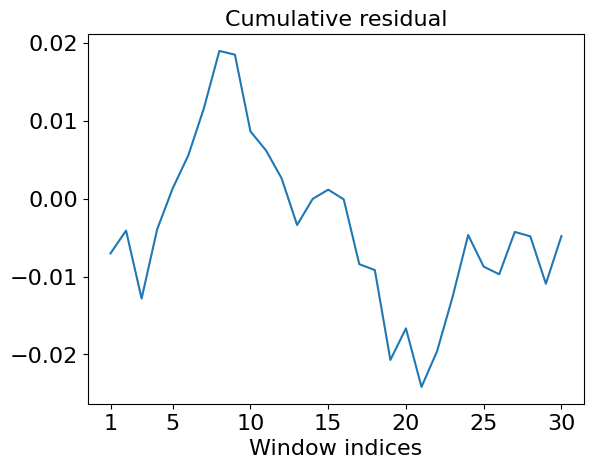

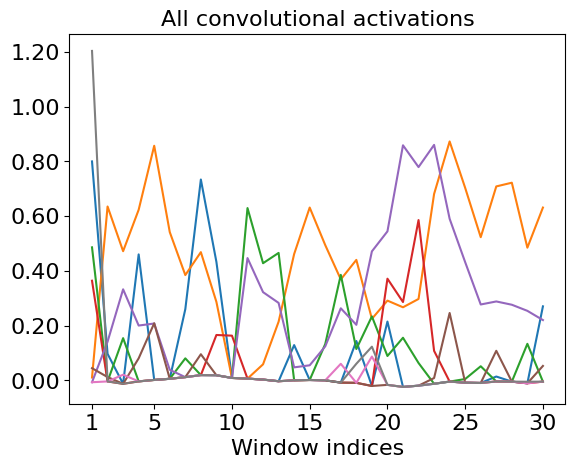

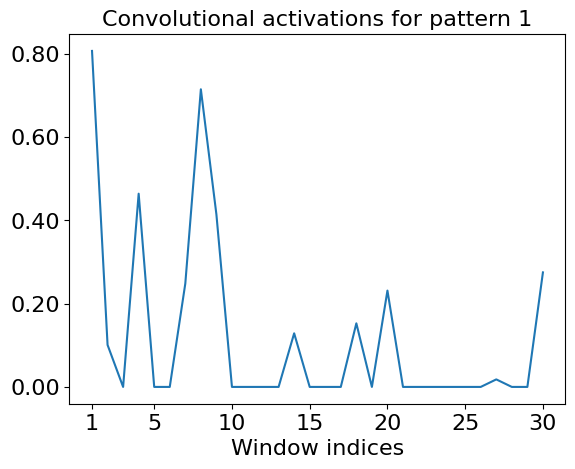

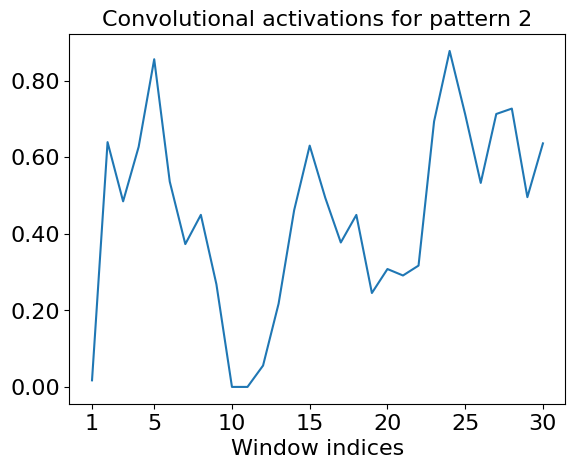

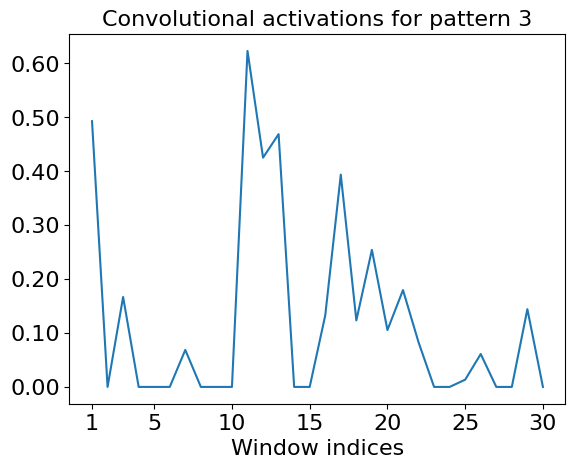

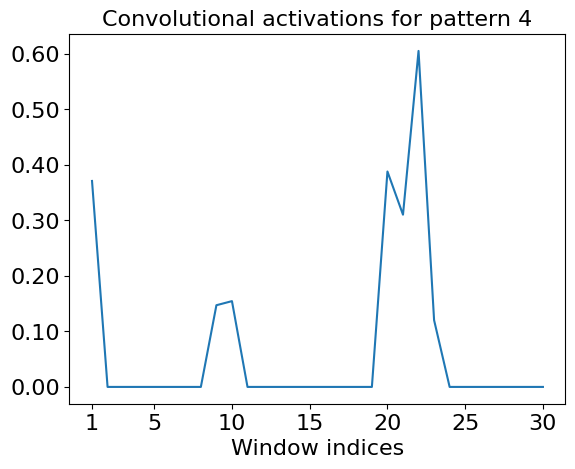

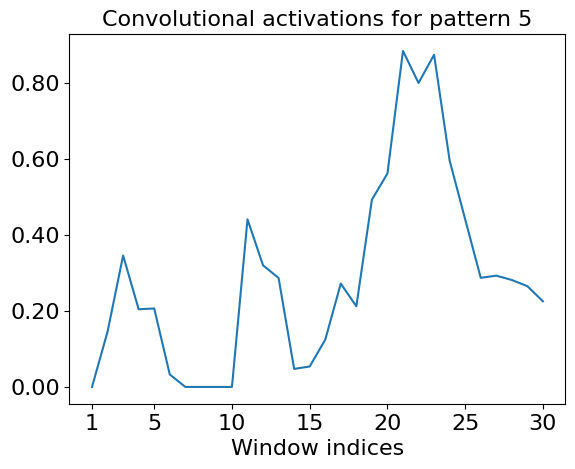

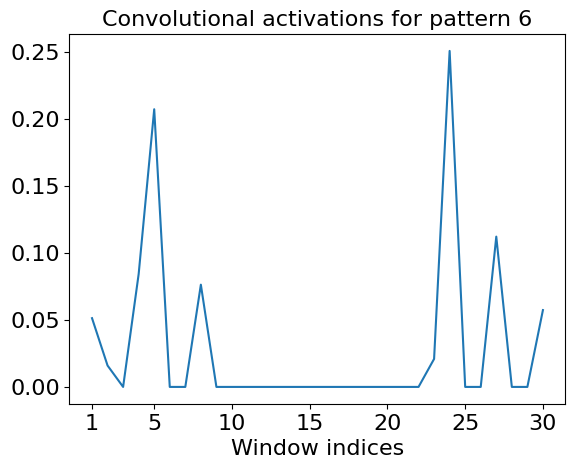

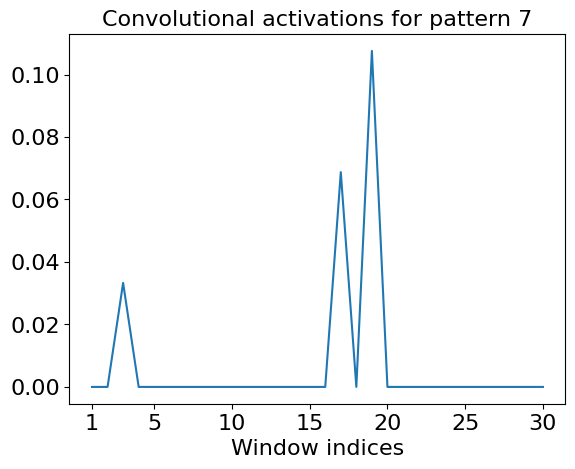

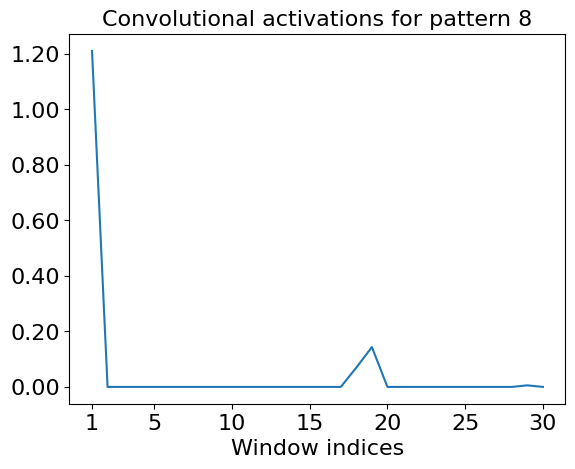

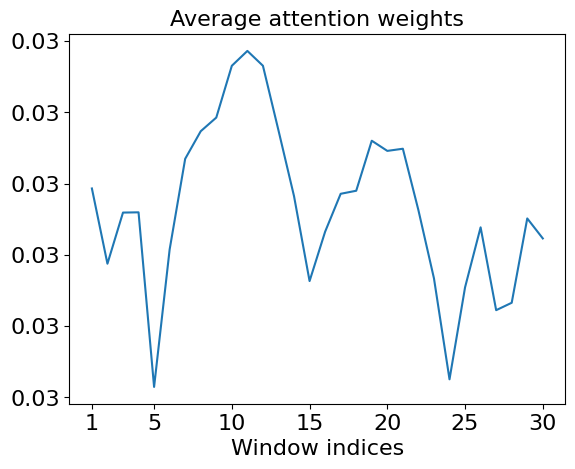

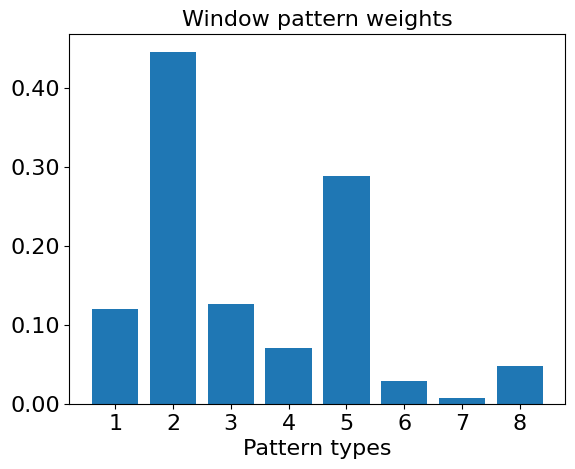

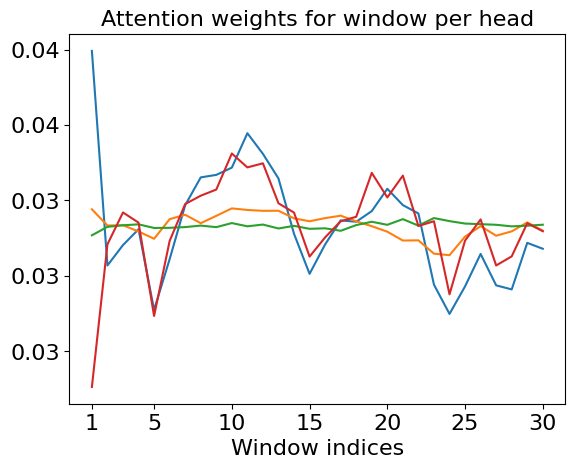

In [42]:
SMALL_SIZE = 16
BIGGER_SIZE = 18

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=SMALL_SIZE)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize

# Plots of individual windows
l = 0
num_heads = 4
time = 40
    
# Plot of cumulative residuals
plt.figure()
plt.plot(range(lookback),windows[l,time])
plt.title('Cumulative residual')
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.2f}'))
plt.xticks(ticks=[0]+list(range(4,lookback,5)), labels=[1]+list(range(5,lookback+1,5)), rotation = 0)
plt.xlabel('Window indices')
# plt.savefig('SimulationPlots/'+f"CumResWindow{l}.png",bbox_inches='tight')
plt.show()

# Plots of some convolutional hidden states
plt.figure()
for i in range(filter_numbers[-1]):
    plt.plot(range(lookback),states[l,time,:,i], label=f'{i}')
plt.title('All convolutional activations')
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.2f}'))
plt.xticks(ticks=[0]+list(range(4,lookback,5)), labels=[1]+list(range(5,lookback+1,5)), rotation = 0)
plt.xlabel('Window indices')
# plt.savefig('SimulationPlots/'+f"ConvFeaturesWindow{l}.png",bbox_inches='tight')
plt.show()

    
for i in range(filter_numbers[-1]):
    plt.figure()
    plt.plot(range(lookback), convNoRes[l,time,:,i], label=f'{i}')
    plt.title(f'Convolutional activations for pattern {i+1}')
    plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.2f}'))
    plt.xticks(ticks=[0]+list(range(4,lookback,5)), labels=[1]+list(range(5,lookback+1,5)), rotation = 0)
    plt.xlabel('Window indices')
    # plt.savefig('SimulationPlots/'+f"ConvolutionalFeaturesNoResWindow{i}-{l}.png",bbox_inches='tight')
    plt.show()

plt.figure()
plt.plot(range(lookback),averageAttentionWeights[l,time])
plt.title('Average attention weights')
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.2f}'))
plt.xticks(ticks=[0]+list(range(4,lookback,5)), labels=[1]+list(range(5,lookback+1,5)), rotation = 0)
plt.xlabel('Window indices')
# plt.savefig('SimulationPlots/'+f"AverageAttentionWeightsWindow{l}.png",bbox_inches='tight')
plt.show()

# Plots of some attentional states
if model.useTransformer:
    plt.figure()
    plt.bar(range(1, filter_numbers[-1] + 1) , windowPattern[l,time])
    plt.title('Window pattern weights')
    plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.2f}'))
    plt.xticks(ticks=range(1,filter_numbers[-1]+1), labels=range(1,filter_numbers[-1]+1), rotation = 0)
    plt.xlabel('Pattern types')
    # plt.savefig('SimulationPlots/'+f"PatternWindow{l}.png",bbox_inches='tight')
    plt.show()
    
    # sns.heatmap(attention_weights[l,time:(time+1),:,0])# vmax = 0.25)
    # pd.DataFrame(attention_weights[l,time].T).plot()#.bar()
    plt.figure()
    for i in range(num_heads):
        plt.plot(attention_weights[l,time,i,:], label = f"Head {i}")
    plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.2f}'))
    plt.xticks(ticks=[0]+list(range(4,lookback,5)), labels=[1]+list(range(5,lookback+1,5)), rotation = 0)
    plt.xlabel('Window indices')
    plt.title("Attention weights for window per head")
    # plt.savefig('SimulationPlots/'+f"AttentionWeightsWindow{l}.png",bbox_inches='tight')
    plt.show()